# Front Matter
Here we define everything we need in order to get the model set up

NOte that in addition to the packages you see below, you'll need to install `pytables` to save dataframes to disk.

In [46]:
import os
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"
import json 
import os, shutil
import glob
import numpy as np
import pandas as pd
import sys
from pprint import pformat
from tempfile import TemporaryDirectory

import flopy
from flopy.utils.gridintersect import GridIntersect
import rasterio as rio
from rasterio import plot as rioplot
from matplotlib import pyplot as plt

#import rasterio as rio
import geopandas as gpd
import rasterio
from rasterio.merge import merge
import matplotlib as mpl
import matplotlib.pyplot as plt
from rasterio.enums import Resampling
from affine import Affine
import warnings

# shapely 2.x deprecation warning from pyogrio
warnings.filterwarnings("ignore", message=".*shapely.geos.*", category=DeprecationWarning)

# flopy GridIntersect future-change warning
warnings.filterwarnings("ignore", message=".*GridIntersect.*GeoDataFrame.*", category=DeprecationWarning)


print(sys.version)
print(f"numpy version: {np.__version__}")
print(f"matplotlib version: {mpl.__version__}")
print(f"flopy version: {flopy.__version__}")

3.13.12 | packaged by conda-forge | (main, Feb  5 2026, 05:41:12) [MSC v.1944 64 bit (AMD64)]
numpy version: 2.3.5
matplotlib version: 3.10.8
flopy version: 3.10.0


## Specify model directories

In [2]:
# Model input files directory
dirInFiles = r'D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers'

# Base model files directory--the actual models will be created in a subdirectory. The 
dirModelFilesBase = r'D:\Users\abolmaal\modelling\Modflow'

# Model executables directory (will be copied to the model base directory for the run)
dirExec = r'D:\Users\abolmaal\modelling\Modflow\helper'

## Define Inputs and Model Properties

In [3]:
# Specify the name of the simulation
nameSim = 'Greatlakes'

# Specify the name of this model 
nameModel = 'Testing'

# Check that names don't exceed the 16 character limit in MODFLOW6
nameModel = '%.16s'%nameModel

# List directories to create, base directory needs to be listed first
dirModelFiles = os.path.join(dirModelFilesBase,nameModel)
createDirs = [dirModelFiles]

# Specify Model Inputs

### Build monthly tdis 

In [ ]:
from datetime import datetime
import calendar
import pandas as pd
import flopy
# create simulation
sim = flopy.mf6.MFSimulation(
    sim_name=nameModel, version="mf6", exe_name="mf6", sim_ws=dirModelFiles
)

def build_monthly_perioddata(start="2000-01-01", end="2025-12-01", nstp=1, tsmult=1.0):
    """
    Build MODFLOW 6 TDIS perioddata for monthly stress periods.
    start/end are month-start strings (YYYY-MM-01). end is inclusive month-start.
    Returns:
      perioddata: list of tuples (perlen_days, nstp, tsmult)
      months: pandas.DatetimeIndex of month starts
    """
    months = pd.date_range(start=start, end=end, freq="MS")  # MS = month start
    perioddata = []
    for d in months:
        ndays = calendar.monthrange(d.year, d.month)[1]     # correct leap years
        perioddata.append((float(ndays), int(nstp), float(tsmult)))
    return perioddata, months

# example usage when you create your simulation:
# sim = flopy.mf6.MFSimulation(sim_name=nameSim, exe_name=exe_path, sim_ws=dirModelFiles)

perioddata, months = build_monthly_perioddata("2000-01-01", "2025-12-01", nstp=1, tsmult=1.0)

tdis = flopy.mf6.ModflowTdis(
    sim,
    time_units="DAYS",
    nper=len(perioddata),
    perioddata=perioddata,
    start_date_time="2000-01-01"
)

print("Stress periods:", len(perioddata))
print("First 3 perlen:", perioddata[:3])
print("Last 3 perlen:", perioddata[-3:])

In [11]:
# Input Rasters
nameInputTop = r'D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\DEM\DEM_merged_3174_30m.tif'
nameInputLayBot = r'D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Bottom\modelbottom.tif'
nameInputIbound = r'D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Ibound\extendedBdry_jan26_adk.tif'
nameInputStart = r'D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Costantheads\domain_water_mask_30m_buff2000m.tif'
nameInputHorizCond = r'D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\HK\HK_multiband.tif'
nameInputVertAni = 'vani'
nameInputRech = r'D:\Users\abolmaal\modelling\Projects\GreatLakes\outputs\NOAH_annual_recharge_2000_2024_1.nc'

# Specify the extension on the input grid names
extInput = '.tif'

# Inputs specific to the constant head features
pathInputConstHead = r'D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Costantheads\CHD_zone_shoreband_1000m.shp'
fieldInputConstHeadElev = 'Elev'

# Inputs specific to the drain features
pathInputDrn = r'D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\NHD\streams_merged_clip_to_bdry.shp'
fieldInputDrnWidth = 'WIDTH_M'

# Specify the executable name to use
nameModflowExec = 'mf6.exe'

# Specify model time structural parameters
structure = dict()
structure["name"]   = nameModel
structure["perlen"] = [p[0] for p in perioddata]
structure["nstp"]   = [p[1] for p in perioddata]
structure["tsmult"] = [p[2] for p in perioddata]
structure["steady"] = [False] * len(perioddata)   # length = 312

### Specify any other constants used below

In [6]:
# Specify the MODFLOW version string
versionString = 'mf6'

# Specify a nodata value to use
noDataValue = -999

# Specify the conversion factor to get recharge into m/d
rechConv = 1/366 #comes in m/yr

### Output Names

In [7]:
# Model outputs
nameOutInputsStore = 'model_inputs.h5'
nameOutInputsNumpy = 'model_inputs.npz'

## Helper Functions

In [39]:
def read_raster(inFile, band=1, nanVal=np.nan, dtype="float32"):
    with rio.open(inFile) as src:
        nodata = src.nodata
        arr = src.read(band).astype(dtype, copy=False)

    if nodata is not None:
        arr = np.where(arr == nodata, nanVal, arr)

    return arr

def get_raster_header(inFile):
    # Read in the raster header
    with rio.open(inFile) as src:
        inMeta = src.meta
        inCRS = src.crs
        inTransform = src.transform
        
    return inMeta, inCRS, inTransform

def get_raster_extent_cellsizes(inMeta):
    # Pull the transform
    transform = inMeta['transform']

    (minX,maxY) = transform * (0,0)
    (maxX,minY) = transform * (inMeta['width'],inMeta['height'])

    cellSizeX = transform[0]
    cellSizeY = -transform[4]
    
    return (minX,maxX,minY,maxY), (cellSizeX,cellSizeY)

def plot_raster(data, transform=None, label=None, title=None, cmap="viridis",
                ax=None, vmax=None, vmin=None, despine=False):
    if ax is None:
        fig, ax = plt.subplots()

    if transform is not None:
        im = rioplot.show(data, transform=transform, ax=ax, cmap=cmap, vmax=vmax, vmin=vmin)
        # rioplot.show returns an AxesImage only sometimes; safest is grab last image:
        im = ax.images[-1] if ax.images else None
    else:
        im = ax.imshow(data, cmap=cmap, vmax=vmax, vmin=vmin)

    if title:
        ax.set_title(title)

    if im is not None:
        plt.colorbar(im, ax=ax, shrink=0.5, label=label)

    if despine:
        for s in ax.spines.values():
            s.set_visible(False)
        ax.set_xticks([])
        ax.set_yticks([])

    return ax

def intersect_grid_feature(objIntsct, pathFeature, lay=0, addFields=None):
    addFields = addFields or []
    gdfFeature = gpd.read_file(pathFeature)

    dfIntsct_list = []

    for m in range(len(gdfFeature)):
        geom = gdfFeature.geometry.iloc[m]

        dfResult = pd.DataFrame(objIntsct.intersect(geom))

        # carry attributes
        for thisField in addFields:
            dfResult[thisField] = gdfFeature[thisField].iloc[m]

        # cellids from GridIntersect are typically (row, col)
        dfResult["cellids_rc"] = dfResult["cellids"]

        # add layer: (lay, row, col)
        dfResult["cellids"] = dfResult["cellids_rc"].apply(lambda rc: (lay, rc[0], rc[1]))

        dfResult["lay"] = lay
        dfResult["row"] = dfResult["cellids"].apply(lambda x: x[1])
        dfResult["col"] = dfResult["cellids"].apply(lambda x: x[2])

        dfIntsct_list.append(dfResult)

    return pd.concat(dfIntsct_list, ignore_index=True) if dfIntsct_list else pd.DataFrame()



def read_raster_preview_multiband(path, max_dim=2000, bands=None, resampling=Resampling.nearest):
    """
    Reads a raster at reduced resolution for preview.
    Returns:
      data: (nbands, out_h, out_w)
      transform: Affine transform for the preview array
      crs: CRS
    """
    with rio.open(path) as src:
        scale = max(src.width / max_dim, src.height / max_dim, 1)
        out_w = int(src.width / scale)
        out_h = int(src.height / scale)

        # Choose bands
        if bands is None:
            # read all bands -> shape (count, out_h, out_w)
            data = src.read(
                out_shape=(src.count, out_h, out_w),
                resampling=resampling
            )
        else:
            # bands should be 1-based list like [1,2,3]
            data = src.read(
                bands,
                out_shape=(len(bands), out_h, out_w),
                resampling=resampling
            )

        # Update transform for the resampled shape
        sx = src.width / out_w
        sy = src.height / out_h
        transform = src.transform * Affine.scale(sx, sy)

        return data, transform, src.crs


def estimate_grid(boundary_shp, epsg=3174, cellsize=5000):
    gdf = gpd.read_file(boundary_shp).to_crs(epsg=epsg)
    xmin, ymin, xmax, ymax = gdf.total_bounds
    width  = int(np.ceil((xmax - xmin) / cellsize))
    height = int(np.ceil((ymax - ymin) / cellsize))
    print(f"EPSG:{epsg}, cellsize={cellsize} m -> grid {height} rows x {width} cols = {height*width:,} cells")
    



def make_gridintersect(modelgrid):
    # works across different FloPy versions
    try:
        return GridIntersect(modelgrid, method="vertex")  # newer signature
    except TypeError:
        try:
            return GridIntersect(modelgrid, "vertex")      # method as positional
        except TypeError:
            return GridIntersect(modelgrid)               # fallback to defaults



### Align BOTM to match IBOUND (disk-to-disk, no huge RAM arrays)

In [ ]:
import rasterio as rio
from rasterio.warp import reproject, Resampling

def warp_raster_to_template(
    src_path,
    template_path,
    out_path,
    resampling=Resampling.bilinear,  # bilinear is good for continuous surfaces (top/botm/hk)
    dst_nodata=None,
    compress="deflate",
    bigtiff="YES",
):
    """
    This function writes a new GeoTIFF with exactly the template’s 
    CRS/transform/shape, and uses rasterio.warp.reproject band-by-band
    (so you don’t allocate a billion-cell array in memory).
    
    Warp (reproject/resample) src raster to match template raster's grid:
    - same CRS
    - same transform
    - same width/height
    Works for multiband rasters.
    Writes output to disk (memory-safe for huge rasters).
    """
    with rio.open(template_path) as tmpl, rio.open(src_path) as src:
        dst_crs = tmpl.crs
        dst_transform = tmpl.transform
        dst_width = tmpl.width
        dst_height = tmpl.height

        # nodata handling
        src_nodata = src.nodata
        if dst_nodata is None:
            dst_nodata = src_nodata

        # output metadata (use src dtype/band count, but template grid)
        dst_meta = src.meta.copy()
        dst_meta.update(
            driver="GTiff",
            crs=dst_crs,
            transform=dst_transform,
            width=dst_width,
            height=dst_height,
            nodata=dst_nodata,
            compress=compress,
            BIGTIFF=bigtiff,
            tiled=True,
            blockxsize=512,
            blockysize=512,
        )

        with rio.open(out_path, "w", **dst_meta) as dst:
            for b in range(1, src.count + 1):
                reproject(
                    source=rio.band(src, b),
                    destination=rio.band(dst, b),
                    src_transform=src.transform,
                    src_crs=src.crs,
                    src_nodata=src_nodata,
                    dst_transform=dst_transform,
                    dst_crs=dst_crs,
                    dst_nodata=dst_nodata,
                    resampling=resampling,
                )

    return out_path

In [18]:
template = nameInputIbound          # use IBOUND as the master grid
src_botm = nameInputLayBot

out_botm_aligned = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Bottom\modelbottom_ALIGNED_TO_IBOUND.tif"

warp_raster_to_template(
    src_path=src_botm,
    template_path=template,
    out_path=out_botm_aligned,
    resampling=Resampling.bilinear
)

# Now read header from aligned BOTM and set numLay from that
meta_bot, crs_bot, transform_bot = get_raster_header(out_botm_aligned)
structure["numLay"] = meta_bot["count"]
print("Aligned BOTM numLay:", structure["numLay"])

Aligned BOTM numLay: 1


### Rasterize boundary polygon → idomain (0/1) aligned to template

In [ ]:
import numpy as np
import geopandas as gpd
import rasterio as rio
from rasterio.features import rasterize
from pathlib import Path

def rasterize_polygon_to_idomain(boundary_shp, template_tif, out_idomain_tif, burn_value=1):
    """
    Create an MF6-ready idomain raster (0=inactive, 1=active) aligned to template_tif.
    """
    gdf = gpd.read_file(boundary_shp)

    with rio.open(template_tif) as tmp:
        # Reproject boundary polygon to template CRS
        if gdf.crs is None:
            raise ValueError("Boundary shapefile has no CRS defined.")
        gdf = gdf.to_crs(tmp.crs)

        shapes = [(geom, burn_value) for geom in gdf.geometry if geom is not None]

        arr = rasterize(
            shapes=shapes,
            out_shape=(tmp.height, tmp.width),
            transform=tmp.transform,
            fill=0,
            dtype="int32",
            all_touched=False  # set True if you want a slightly fatter boundary
        )

        meta = tmp.meta.copy()
        meta.update(
            dtype="int32",
            count=1,
            nodata=0,
            compress="deflate",
            tiled=True,
            BIGTIFF="YES",
            blockxsize=512,
            blockysize=512,
        )

        Path(out_idomain_tif).parent.mkdir(parents=True, exist_ok=True)
        with rio.open(out_idomain_tif, "w", **meta) as dst:
            dst.write(arr, 1)

    return out_idomain_tif

In [ ]:
out_idomain  = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Ibound\idomain_derived_1.tif"
rasterize_polygon_to_idomain(boundary_shp, nameInputIbound, out_idomain, burn_value=1)

In [27]:
boundary_shp = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Ibound\extended_Bdry_final_GLB_Albers.shp"
for cs in [1000, 2000, 5000, 10000]:
    estimate_grid(boundary_shp, epsg=3174, cellsize=cs)

EPSG:3174, cellsize=1000 m -> grid 1248 rows x 1526 cols = 1,904,448 cells
EPSG:3174, cellsize=2000 m -> grid 624 rows x 763 cols = 476,112 cells
EPSG:3174, cellsize=5000 m -> grid 250 rows x 306 cols = 76,500 cells
EPSG:3174, cellsize=10000 m -> grid 125 rows x 153 cols = 19,125 cells


In [28]:
# Create a template raster from your boundary polygon
import numpy as np
import geopandas as gpd
import rasterio as rio
from rasterio.transform import from_origin
from rasterio.features import rasterize
from pathlib import Path

boundary_shp = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Ibound\extended_Bdry_final_GLB_Albers.shp"

OUT_GRID_DIR = Path(r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\GRID_3174")
OUT_GRID_DIR.mkdir(parents=True, exist_ok=True)

CELL = 5000   # <- change to 2000 or 1000 if you want
EPSG = 3174

template_tif = str(OUT_GRID_DIR / f"template_{CELL}m_epsg{EPSG}.tif")
idomain_tif  = str(OUT_GRID_DIR / f"idomain_{CELL}m_epsg{EPSG}.tif")

def make_template_from_boundary(boundary_shp, out_template_tif, cellsize, epsg=3174):
    gdf = gpd.read_file(boundary_shp).to_crs(epsg=epsg)
    xmin, ymin, xmax, ymax = gdf.total_bounds

    width  = int(np.ceil((xmax - xmin) / cellsize))
    height = int(np.ceil((ymax - ymin) / cellsize))

    transform = from_origin(xmin, ymax, cellsize, cellsize)

    meta = {
        "driver": "GTiff",
        "height": height,
        "width": width,
        "count": 1,
        "dtype": "int16",
        "crs": gdf.crs,
        "transform": transform,
        "nodata": 0,
        "compress": "deflate",
        "tiled": True,
        "BIGTIFF": "YES",
        "blockxsize": 256,
        "blockysize": 256,
    }

    Path(out_template_tif).parent.mkdir(parents=True, exist_ok=True)
    with rio.open(out_template_tif, "w", **meta) as dst:
        dst.write(np.zeros((height, width), dtype=np.int16), 1)

    print("Template grid:", height, "rows x", width, "cols =", height*width, "cells")
    print("Wrote:", out_template_tif)
    return out_template_tif

def rasterize_idomain(boundary_shp, template_tif, out_idomain_tif, burn_value=1, all_touched=False):
    gdf = gpd.read_file(boundary_shp)

    with rio.open(template_tif) as tmp:
        gdf = gdf.to_crs(tmp.crs)

        shapes = [(geom, burn_value) for geom in gdf.geometry if geom is not None]

        arr = rasterize(
            shapes=shapes,
            out_shape=(tmp.height, tmp.width),
            transform=tmp.transform,
            fill=0,
            dtype="int32",
            all_touched=all_touched
        )

        meta = tmp.meta.copy()
        meta.update(dtype="int32", count=1, nodata=0, compress="deflate", tiled=True, BIGTIFF="YES")

        with rio.open(out_idomain_tif, "w", **meta) as dst:
            dst.write(arr, 1)

    print("Active cells in idomain:", int(np.count_nonzero(arr)))
    print("Wrote:", out_idomain_tif)
    return out_idomain_tif

make_template_from_boundary(boundary_shp, template_tif, CELL, epsg=EPSG)
rasterize_idomain(boundary_shp, template_tif, idomain_tif, burn_value=1, all_touched=False)

Template grid: 250 rows x 306 cols = 76500 cells
Wrote: D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\GRID_3174\template_5000m_epsg3174.tif
Active cells in idomain: 38683
Wrote: D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\GRID_3174\idomain_5000m_epsg3174.tif


'D:\\Users\\abolmaal\\modelling\\Modflow\\Prep\\GreatLakes\\model_Layers\\GRID_3174\\idomain_5000m_epsg3174.tif'

In [29]:
import rasterio as rio
from rasterio.warp import reproject, Resampling
from pathlib import Path

ALIGNED_DIR = Path(r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\ALIGNED_3174")
ALIGNED_DIR.mkdir(parents=True, exist_ok=True)

def warp_raster_to_template(src_path, template_path, out_path, resampling, dst_nodata=None):
    with rio.open(template_path) as tmpl, rio.open(src_path) as src:
        dst_crs = tmpl.crs
        dst_transform = tmpl.transform
        dst_width = tmpl.width
        dst_height = tmpl.height

        src_nodata = src.nodata
        if dst_nodata is None:
            dst_nodata = src_nodata

        dst_meta = src.meta.copy()
        dst_meta.update(
            driver="GTiff",
            crs=dst_crs,
            transform=dst_transform,
            width=dst_width,
            height=dst_height,
            nodata=dst_nodata,
            compress="deflate",
            tiled=True,
            BIGTIFF="YES",
            blockxsize=256,
            blockysize=256,
        )

        with rio.open(out_path, "w", **dst_meta) as dst:
            for b in range(1, src.count + 1):
                reproject(
                    source=rio.band(src, b),
                    destination=rio.band(dst, b),
                    src_transform=src.transform,
                    src_crs=src.crs,
                    src_nodata=src_nodata,
                    dst_transform=dst_transform,
                    dst_crs=dst_crs,
                    dst_nodata=dst_nodata,
                    resampling=resampling,
                )
    print("Wrote:", out_path)
    return out_path

# Your inputs (original)
src_top  = nameInputTop
src_botm = nameInputLayBot
src_hk   = nameInputHorizCond
src_chdmask = nameInputStart  # if this is a raster mask

top_aligned  = str(ALIGNED_DIR / f"TOP_{CELL}m.tif")
botm_aligned = str(ALIGNED_DIR / f"BOTM_{CELL}m.tif")
hk_aligned   = str(ALIGNED_DIR / f"HK_{CELL}m.tif")
chdmask_aligned = str(ALIGNED_DIR / f"CHDmask_{CELL}m.tif")

warp_raster_to_template(src_top,  template_tif, top_aligned,  Resampling.bilinear)
warp_raster_to_template(src_botm, template_tif, botm_aligned, Resampling.bilinear)
warp_raster_to_template(src_hk,   template_tif, hk_aligned,   Resampling.bilinear)
warp_raster_to_template(src_chdmask, template_tif, chdmask_aligned, Resampling.nearest)

Wrote: D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\ALIGNED_3174\TOP_5000m.tif
Wrote: D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\ALIGNED_3174\BOTM_5000m.tif
Wrote: D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\ALIGNED_3174\HK_5000m.tif
Wrote: D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\ALIGNED_3174\CHDmask_5000m.tif


'D:\\Users\\abolmaal\\modelling\\Modflow\\Prep\\GreatLakes\\model_Layers\\ALIGNED_3174\\CHDmask_5000m.tif'

In [30]:
import numpy as np
import rasterio as rio
from pathlib import Path

def mask_raster_by_idomain(in_raster, idomain_raster, out_raster, nodata_out=None):
    """
    Sets cells OUTSIDE idomain==1 to nodata_out.
    Works for single-band and multi-band rasters, streaming by blocks (memory safe).
    Assumes in_raster and idomain_raster are already on the same grid.
    """
    with rio.open(idomain_raster) as idm, rio.open(in_raster) as src:
        # grid must match
        assert (src.width == idm.width and src.height == idm.height and
                src.transform == idm.transform and src.crs == idm.crs), "Grid mismatch—warp to template first."

        # choose nodata
        if nodata_out is None:
            nodata_out = src.nodata
        if nodata_out is None:
            # provide a safe default depending on dtype
            nodata_out = -9999.0 if np.issubdtype(src.dtypes[0], np.floating) else -9999

        meta = src.meta.copy()
        meta.update(nodata=nodata_out, compress="deflate", tiled=True, BIGTIFF="YES")

        Path(out_raster).parent.mkdir(parents=True, exist_ok=True)
        with rio.open(out_raster, "w", **meta) as dst:
            for _, window in src.block_windows(1):
                m = idm.read(1, window=window)  # 0/1
                mask_outside = (m == 0)

                for b in range(1, src.count + 1):
                    a = src.read(b, window=window)
                    a = a.copy()
                    a[mask_outside] = nodata_out
                    dst.write(a, b, window=window)

    print("Masked to boundary ->", out_raster)
    return out_raster

# Enforce the boundary AFTER warping

top_masked  = str(ALIGNED_DIR / f"TOP_{CELL}m_MASKED.tif")
botm_masked = str(ALIGNED_DIR / f"BOTM_{CELL}m_MASKED.tif")
hk_masked   = str(ALIGNED_DIR / f"HK_{CELL}m_MASKED.tif")

mask_raster_by_idomain(top_aligned,  idomain_tif, top_masked)
mask_raster_by_idomain(botm_aligned, idomain_tif, botm_masked)
mask_raster_by_idomain(hk_aligned,   idomain_tif, hk_masked)


Masked to boundary -> D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\ALIGNED_3174\TOP_5000m_MASKED.tif
Masked to boundary -> D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\ALIGNED_3174\BOTM_5000m_MASKED.tif
Masked to boundary -> D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\ALIGNED_3174\HK_5000m_MASKED.tif


'D:\\Users\\abolmaal\\modelling\\Modflow\\Prep\\GreatLakes\\model_Layers\\ALIGNED_3174\\HK_5000m_MASKED.tif'

## Prepare Environment
This will also create directories if not already done

In [52]:
from pathlib import Path
import flopy

# --- paths ---
exe_path = str((Path(r"D:\Users\abolmaal\modelling\Modflow\helper") / "mf6.exe").resolve())
sim_ws = str(Path(dirModelFilesBase) / nameModel)
Path(sim_ws).mkdir(parents=True, exist_ok=True)

# --- simulation ---
sim = flopy.mf6.MFSimulation(sim_name=nameSim, sim_ws=sim_ws, exe_name=exe_path)

# time discretization (you already built perioddata for 312 months)
tdis = flopy.mf6.ModflowTdis(
    sim,
    time_units="DAYS",
    nper=len(perioddata),
    perioddata=perioddata,
    start_date_time="2000-01-01"
)

# solver
ims = flopy.mf6.ModflowIms(sim, pname="ims", complexity="SIMPLE")

# groundwater flow model
gwf = flopy.mf6.ModflowGwf(sim, modelname=nameModel, save_flows=True)

# link ims to gwf (some flopy versions need this explicitly)
try:
    sim.register_ims_package(ims, [gwf.name])
except Exception:
    pass

print("Created sim + gwf:", gwf.name, "workspace:", sim_ws)

Created sim + gwf: Testing workspace: D:\Users\abolmaal\modelling\Modflow\Testing


This assumes you already have these arrays on the template grid:

- top2d shape (nrow, ncol)

- botm3d shape (nlay, nrow, ncol)

- idomain shape (nlay, nrow, ncol) (0/1)

- hk3d shape (nlay, nrow, ncol) (or you’ve mapped it to layers)

- delr, delc, xorigin, yorigin from the template

If you don’t have xorigin/yorigin handy, I show how to compute them below.

# Common Model Inputs

## Read in Model Inputs
<div class="alert alert-info">
You can skip this entire section if you are going to import previously prepared inputs, below.
</div>

### Active model area
Creates numpy array `rasterIbound`

### Create the model grid template + idomain (0/1)

In [34]:
import numpy as np
import geopandas as gpd
import rasterio as rio
from rasterio.transform import from_origin
from rasterio.features import rasterize
from pathlib import Path

CELL = 5000
EPSG = 3174

GRID_DIR = Path(r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\GRID_3174")
GRID_DIR.mkdir(parents=True, exist_ok=True)

template_tif = str(GRID_DIR / f"template_{CELL}m_epsg{EPSG}.tif")
idomain_tif  = str(GRID_DIR / f"idomain_{CELL}m_epsg{EPSG}.tif")

def make_template_from_boundary(boundary_shp, out_template_tif, cellsize, epsg=3174):
    gdf = gpd.read_file(boundary_shp).to_crs(epsg=epsg)
    xmin, ymin, xmax, ymax = gdf.total_bounds
    width  = int(np.ceil((xmax - xmin) / cellsize))
    height = int(np.ceil((ymax - ymin) / cellsize))
    transform = from_origin(xmin, ymax, cellsize, cellsize)

    meta = dict(
        driver="GTiff", height=height, width=width, count=1, dtype="int16",
        crs=gdf.crs, transform=transform, nodata=0,
        compress="deflate", tiled=True, BIGTIFF="YES", blockxsize=256, blockysize=256
    )

    with rio.open(out_template_tif, "w", **meta) as dst:
        dst.write(np.zeros((height, width), dtype=np.int16), 1)

    print("Template:", height, "x", width, "cells =", height*width)
    return out_template_tif

def rasterize_idomain(boundary_shp, template_tif, out_idomain_tif, burn_value=1, all_touched=False):
    gdf = gpd.read_file(boundary_shp)
    with rio.open(template_tif) as tmp:
        gdf = gdf.to_crs(tmp.crs)
        shapes = [(geom, burn_value) for geom in gdf.geometry if geom is not None]
        arr = rasterize(
            shapes=shapes, out_shape=(tmp.height, tmp.width),
            transform=tmp.transform, fill=0, dtype="int32",
            all_touched=all_touched
        )
        meta = tmp.meta.copy()
        meta.update(dtype="int32", count=1, nodata=0, compress="deflate", tiled=True, BIGTIFF="YES")
        with rio.open(out_idomain_tif, "w", **meta) as dst:
            dst.write(arr, 1)

    print("Active cells:", int(np.count_nonzero(arr)))
    return out_idomain_tif

make_template_from_boundary(boundary_shp, template_tif, CELL, epsg=EPSG)
rasterize_idomain(boundary_shp, template_tif, idomain_tif, burn_value=1, all_touched=False)

Template: 250 x 306 cells = 76500
Active cells: 38683


'D:\\Users\\abolmaal\\modelling\\Modflow\\Prep\\GreatLakes\\model_Layers\\GRID_3174\\idomain_5000m_epsg3174.tif'

# Warp all rasters to the template grid

In [35]:
import rasterio as rio
from rasterio.warp import reproject, Resampling

ALIGNED_DIR = Path(r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\ALIGNED_3174")
ALIGNED_DIR.mkdir(parents=True, exist_ok=True)

def warp_raster_to_template(src_path, template_path, out_path, resampling):
    with rio.open(template_path) as tmpl, rio.open(src_path) as src:
        dst_meta = src.meta.copy()
        dst_meta.update(
            driver="GTiff",
            crs=tmpl.crs,
            transform=tmpl.transform,
            width=tmpl.width,
            height=tmpl.height,
            nodata=src.nodata,
            compress="deflate",
            tiled=True,
            BIGTIFF="YES",
            blockxsize=256,
            blockysize=256,
        )

        with rio.open(out_path, "w", **dst_meta) as dst:
            for b in range(1, src.count + 1):
                reproject(
                    source=rio.band(src, b),
                    destination=rio.band(dst, b),
                    src_transform=src.transform,
                    src_crs=src.crs,
                    src_nodata=src.nodata,
                    dst_transform=tmpl.transform,
                    dst_crs=tmpl.crs,
                    dst_nodata=src.nodata,
                    resampling=resampling,
                )
    print("Wrote:", out_path)
    return out_path

top_aligned  = str(ALIGNED_DIR / f"TOP_{CELL}m.tif")
botm_aligned = str(ALIGNED_DIR / f"BOTM_{CELL}m.tif")
hk_aligned   = str(ALIGNED_DIR / f"HK_{CELL}m.tif")

warp_raster_to_template(nameInputTop,      template_tif, top_aligned,  Resampling.bilinear)
warp_raster_to_template(nameInputLayBot,   template_tif, botm_aligned, Resampling.bilinear)
warp_raster_to_template(nameInputHorizCond,template_tif, hk_aligned,   Resampling.bilinear)

# If nameInputStart is truly a head surface, align it too:
start_aligned = str(ALIGNED_DIR / f"START_{CELL}m.tif")
warp_raster_to_template(nameInputStart, template_tif, start_aligned, Resampling.bilinear)

Wrote: D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\ALIGNED_3174\TOP_5000m.tif
Wrote: D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\ALIGNED_3174\BOTM_5000m.tif
Wrote: D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\ALIGNED_3174\HK_5000m.tif
Wrote: D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\ALIGNED_3174\START_5000m.tif


'D:\\Users\\abolmaal\\modelling\\Modflow\\Prep\\GreatLakes\\model_Layers\\ALIGNED_3174\\START_5000m.tif'

In [70]:
import numpy as np
import rasterio as rio

def read_aligned_tif(path):
    with rio.open(path) as src:
        arr = src.read()          # returns (nband, nrow, ncol)
        nd = src.nodata
    # convert nodata to NaN
    if nd is not None:
        arr = arr.astype("float32", copy=False)
        arr[arr == nd] = np.nan
    return arr

rasterTop   = read_aligned_tif(top_aligned)     # (1, nrow, ncol)
rasterBot   = read_aligned_tif(botm_aligned)    # (nband, nrow, ncol) or (1, nrow, ncol)
rasterHK    = read_aligned_tif(hk_aligned)      # (nband, nrow, ncol) or (1, nrow, ncol)
rasterStart = read_aligned_tif(start_aligned)   # (1, nrow, ncol)

# Step 3) Read aligned arrays (this is what goes into DIS/NPF/IC)

In [36]:
import numpy as np
import rasterio as rio

def read_band1(path, dtype="float32"):
    with rio.open(path) as src:
        a = src.read(1).astype(dtype, copy=False)
        return a, src.crs, src.transform

def read_all_bands(path, dtype="float32"):
    with rio.open(path) as src:
        a = src.read().astype(dtype, copy=False)  # (bands, rows, cols)
        return a, src.crs, src.transform

# idomain (2D -> 3D)
id2d, crs_g, transform_g = read_band1(idomain_tif, dtype="int32")
id2d = (id2d > 0).astype(np.int32)

top2d, _, _   = read_band1(top_aligned, dtype="float32")
botm3d, _, _  = read_all_bands(botm_aligned, dtype="float32")  # (nlay,nrow,ncol)
hk3d,  _, _   = read_all_bands(hk_aligned, dtype="float32")    # (nlay,nrow,ncol) if your HK multiband matches layers

nlay = botm3d.shape[0]
idomain = np.repeat(id2d[np.newaxis, :, :], nlay, axis=0)

print("Shapes: top", top2d.shape, "botm", botm3d.shape, "idomain", idomain.shape, "hk", hk3d.shape)
print("Active cells (L1):", int(np.count_nonzero(idomain[0])))

Shapes: top (250, 306) botm (1, 250, 306) idomain (1, 250, 306) hk (3, 250, 306)
Active cells (L1): 38683


# Step 4) Build the FloPy StructuredGrid once (for intersections)

In [40]:
import flopy
import numpy as np

# pull delr/delc from template
with rio.open(template_tif) as tmp:
    delr = np.full(tmp.width,  tmp.transform.a, dtype=float)       # pixel width
    delc = np.full(tmp.height, abs(tmp.transform.e), dtype=float)  # pixel height
    xll = tmp.bounds.left
    yll = tmp.bounds.bottom
    grid_crs = tmp.crs

structuredGrid = flopy.discretization.StructuredGrid(
    nlay=nlay, nrow=tmp.height, ncol=tmp.width,
    delr=delr, delc=delc,
    xoff=xll, yoff=yll, angrot=0
)

ix = make_gridintersect(structuredGrid)
print("GridIntersect ready:", type(ix))

GridIntersect ready: <class 'flopy.utils.gridintersect.GridIntersect'>


### Starting heads
Creates the `rasterStart` numpy array

In [19]:
import rasterio as rio
with rio.open(nameInputStart) as src:
    print("Raster size:", src.height, src.width, "nodata:", src.nodata, "dtype:", src.dtypes)

print("Model grid:", structure["numRow"], structure["numCol"], "layers:", structure["numLay"])


Raster size: 49758 66126 nodata: 0.0 dtype: ('int16',)
Model grid: 44167 52728 layers: 1


### Build monthly recharge arrays (m/day) on your template grid
Creates the numpy array `rasterRech` and creates the output dataframe `dfRecharge`

In [43]:
# 1) Index and sort all monthly files (2000-01 … 2025-12)
from pathlib import Path
import re
import pandas as pd

nldas_root = Path(r"T:\Data\Climate_Data\Gridded\Downloaded\NLDAS_2_monthly\Noah\NLDAS\NLDAS_NOAH0125_M.2.0")

def index_nldas_monthlies(root: Path):
    files = sorted(root.rglob("NLDAS_NOAH0125_M.A*.nc"))
    rows = []
    for f in files:
        m = re.search(r"\.A(\d{6})\.", f.name)  # AYYYYMM
        if not m:
            continue
        yyyymm = m.group(1)
        dt = pd.Timestamp(int(yyyymm[:4]), int(yyyymm[4:6]), 1)
        rows.append((dt, str(f)))
    df = pd.DataFrame(rows, columns=["date", "path"]).sort_values("date").reset_index(drop=True)
    return df

df_nc = index_nldas_monthlies(nldas_root)
print("Found:", len(df_nc), "monthly nc files")
print(df_nc.head())
print(df_nc.tail())

# sanity: expected 312 months
expected = pd.date_range("2000-01-01", "2025-12-01", freq="MS")
missing = expected.difference(df_nc["date"])
print("Missing months:", len(missing))

Found: 562 monthly nc files
        date                                               path
0 1979-01-01  T:\Data\Climate_Data\Gridded\Downloaded\NLDAS_...
1 1979-02-01  T:\Data\Climate_Data\Gridded\Downloaded\NLDAS_...
2 1979-03-01  T:\Data\Climate_Data\Gridded\Downloaded\NLDAS_...
3 1979-04-01  T:\Data\Climate_Data\Gridded\Downloaded\NLDAS_...
4 1979-05-01  T:\Data\Climate_Data\Gridded\Downloaded\NLDAS_...
          date                                               path
557 2025-06-01  T:\Data\Climate_Data\Gridded\Downloaded\NLDAS_...
558 2025-07-01  T:\Data\Climate_Data\Gridded\Downloaded\NLDAS_...
559 2025-08-01  T:\Data\Climate_Data\Gridded\Downloaded\NLDAS_...
560 2025-09-01  T:\Data\Climate_Data\Gridded\Downloaded\NLDAS_...
561 2025-10-01  T:\Data\Climate_Data\Gridded\Downloaded\NLDAS_...
Missing months: 2


2) Function: read one month, convert to m/day, reproject to template grid

In [44]:
import numpy as np
import xarray as xr
import calendar
import rasterio as rio
from rasterio.transform import from_bounds
from rasterio.warp import reproject, Resampling

def qsb_month_to_rech_mday_on_template(nc_path, template_tif, var="Qsb", id2d=None):
    """
    Returns rech2d in m/day on template grid.
    nc variable expected as (time, lat, lon) or (lat, lon).
    Handles units:
      - kg m-2 (monthly accumulated) -> (kg/m2)/1000/days_in_month
      - kg m-2 s-1 (rate) -> *86400/1000
    """
    # --- open netcdf ---
    ds = xr.open_dataset(nc_path)
    da = ds[var]
    if "time" in da.dims:
        da = da.isel(time=0)

    units = (da.attrs.get("units") or "").strip()
    arr = da.values.astype("float32")

    lat = da["lat"].values
    lon = da["lon"].values

    # Ensure north-up array (lat decreasing top->bottom)
    if lat[0] < lat[-1]:
        lat = lat[::-1]
        arr = arr[::-1, :]

    # Build a geotransform using half-cell padding (coords are cell centers)
    dx = float(np.abs(lon[1] - lon[0]))
    dy = float(np.abs(lat[0] - lat[1]))
    left   = lon.min() - dx / 2
    right  = lon.max() + dx / 2
    bottom = lat.min() - dy / 2
    top    = lat.max() + dy / 2
    src_transform = from_bounds(left, bottom, right, top, arr.shape[1], arr.shape[0])
    src_crs = "EPSG:4326"

    # Days in month from filename date
    m = re.search(r"\.A(\d{6})\.", Path(nc_path).name)
    y = int(m.group(1)[:4]); mo = int(m.group(1)[4:6])
    days = calendar.monthrange(y, mo)[1]

    # Convert to m/day
    if "s-1" in units or "/s" in units:
        rech_src = arr * 86400.0 / 1000.0          # kg m-2 s-1 -> m/day
    else:
        rech_src = (arr / 1000.0) / float(days)    # kg m-2 per month -> m/day

    # --- reproject to template grid ---
    with rio.open(template_tif) as tmp:
        dst = np.zeros((tmp.height, tmp.width), dtype="float32")
        reproject(
            source=rech_src,
            destination=dst,
            src_transform=src_transform,
            src_crs=src_crs,
            dst_transform=tmp.transform,
            dst_crs=tmp.crs,
            resampling=Resampling.average,
            dst_nodata=0.0,
        )

    # Mask outside domain
    if id2d is not None:
        dst[id2d == 0] = 0.0

    dst[dst < 0] = 0.0
    ds.close()
    return dst

3) Build rch_spd dictionary for all 312 stress periods

In [47]:
from pathlib import Path
import shutil
import tempfile

def copy_to_local_cached(src_path: str) -> str:
    src = Path(src_path)
    cache_dir = Path(tempfile.gettempdir()) / "nldas_nc_cache"
    cache_dir.mkdir(parents=True, exist_ok=True)

    dst = cache_dir / src.name

    # copy only if missing or changed
    if (not dst.exists()) or (dst.stat().st_size != src.stat().st_size) or (dst.stat().st_mtime < src.stat().st_mtime):
        shutil.copy2(src, dst)

    return str(dst)

In [48]:
import re
import numpy as np
import xarray as xr

def read_qsb_lat_lon(nc_path: str, var="Qsb"):
    """
    Returns: qsb2d, lat1d, lon1d, units_str
    qsb2d is (lat, lon) for the first time index if time exists.
    """
    local_path = copy_to_local_cached(nc_path)

    # Try xarray engines first
    for engine in ("h5netcdf", "netcdf4"):
        try:
            ds = xr.open_dataset(local_path, engine=engine, decode_times=False)
            da = ds[var]
            if "time" in da.dims:
                da = da.isel(time=0)

            units = (da.attrs.get("units") or "").strip()
            qsb = da.values.astype("float32")

            # NLDAS usually has 1D lat/lon coords
            lat = da["lat"].values
            lon = da["lon"].values

            ds.close()
            return qsb, lat, lon, units
        except Exception as e:
            last_err = e

    # Last resort: h5py (avoids some attribute-reading issues)
    try:
        import h5py
        with h5py.File(local_path, "r") as f:
            # Most NLDAS NetCDFs store vars at the root
            q = f[var][...]
            # handle time dimension if present
            if q.ndim == 3:
                q = q[0, :, :]
            qsb = np.array(q, dtype="float32")

            lat = np.array(f["lat"][...])
            lon = np.array(f["lon"][...])

            # units may not be readable or may be bytes
            units = ""
            try:
                units_attr = f[var].attrs.get("units", "")
                if isinstance(units_attr, (bytes, np.bytes_)):
                    units = units_attr.decode("utf-8")
                else:
                    units = str(units_attr)
            except Exception:
                units = ""

        return qsb, lat, lon, units
    except Exception as e2:
        raise RuntimeError(f"Failed to open {nc_path}\n"
                           f"xarray last error: {last_err}\n"
                           f"h5py error: {e2}")

In [49]:
import calendar
import rasterio as rio
from rasterio.transform import from_bounds
from rasterio.warp import reproject, Resampling

def qsb_month_to_rech_mday_on_template(nc_path, template_tif, var="Qsb", id2d=None):
    qsb, lat, lon, units = read_qsb_lat_lon(nc_path, var=var)

    # Ensure north-up (lat decreasing down rows)
    if lat[0] < lat[-1]:
        lat = lat[::-1]
        qsb = qsb[::-1, :]

    # Build src transform from coordinate centers
    dx = float(np.abs(lon[1] - lon[0]))
    dy = float(np.abs(lat[0] - lat[1]))
    left   = float(lon.min() - dx / 2)
    right  = float(lon.max() + dx / 2)
    bottom = float(lat.min() - dy / 2)
    top    = float(lat.max() + dy / 2)

    src_transform = from_bounds(left, bottom, right, top, qsb.shape[1], qsb.shape[0])
    src_crs = "EPSG:4326"

    # Days in month from filename AYYYYMM
    m = re.search(r"\.A(\d{6})\.", Path(nc_path).name)
    if not m:
        raise ValueError(f"Could not parse YYYYMM from filename: {nc_path}")
    y = int(m.group(1)[:4]); mo = int(m.group(1)[4:6])
    days = calendar.monthrange(y, mo)[1]

    # Units handling
    u = (units or "").lower()
    if ("s-1" in u) or ("/s" in u):
        # kg m-2 s-1 -> m/day
        rech_src = qsb * 86400.0 / 1000.0
    else:
        # assume kg m-2 per month -> m/day
        rech_src = (qsb / 1000.0) / float(days)

    # Reproject to model grid
    with rio.open(template_tif) as tmp:
        dst = np.zeros((tmp.height, tmp.width), dtype="float32")
        reproject(
            source=rech_src,
            destination=dst,
            src_transform=src_transform,
            src_crs=src_crs,
            dst_transform=tmp.transform,
            dst_crs=tmp.crs,
            resampling=Resampling.average,   # good when coarsening
            dst_nodata=0.0,
        )

    if id2d is not None:
        dst[id2d == 0] = 0.0

    dst[dst < 0] = 0.0
    return dst

In [50]:
# id2d should be on the template grid (0/1)
# e.g. id2d = (read_band1(idomain_tif, dtype="int32") > 0).astype(np.int32)

rch_spd = {}
bad = []

for per, (dt, pth) in enumerate(zip(df_nc["date"], df_nc["path"])):
    try:
        rch_spd[per] = qsb_month_to_rech_mday_on_template(pth, template_tif, var="Qsb", id2d=id2d)
    except Exception as e:
        bad.append((per, str(dt.date()), pth, repr(e)))
        # fill with zeros so stress period exists
        with rio.open(template_tif) as tmp:
            rch_spd[per] = np.zeros((tmp.height, tmp.width), dtype="float32")

print("Built recharge arrays:", len(rch_spd))
print("Bad files:", len(bad))
if bad:
    print("First bad example:\n", bad[0])

Built recharge arrays: 562
Bad files: 0


## save recharge

In [80]:
import numpy as np
import xarray as xr
import rasterio as rio
from pathlib import Path

def template_xy_coords(template_tif, h, w):
    """Compute x/y coords (cell centers) for a given (h,w) using template transform."""
    with rio.open(template_tif) as tmp:
        t = tmp.transform
        # use the transform, but force the lengths to match (h,w)
        x = t.c + (np.arange(w) + 0.5) * t.a
        y = t.f + (np.arange(h) + 0.5) * t.e
        return x.astype("float64"), y.astype("float64")

def save_rch_zarr(rch_spd, dates, template_tif, zarr_dir, varname="rech_mday"):
    zarr_dir = Path(zarr_dir)
    zarr_dir.parent.mkdir(parents=True, exist_ok=True)

    # ---- verify shapes are consistent ----
    shapes = {k: np.shape(v) for k, v in rch_spd.items()}
    uniq_shapes = sorted(set(shapes.values()))
    if len(uniq_shapes) != 1:
        raise ValueError(f"rch_spd contains mixed shapes: {uniq_shapes}. Example: {list(shapes.items())[:5]}")

    h, w = uniq_shapes[0]
    nt = len(rch_spd)

    if len(dates) != nt:
        raise ValueError(f"dates length ({len(dates)}) != number of stress periods ({nt})")

    # ---- stack ----
    data = np.empty((nt, h, w), dtype="float32")
    for k in range(nt):
        data[k, :, :] = rch_spd[k].astype("float32")

    # ---- coords guaranteed to match data shape ----
    x, y = template_xy_coords(template_tif, h, w)

    ds = xr.Dataset(
        {varname: (("time", "y", "x"), data)},
        coords={"time": np.array(dates), "x": x, "y": y},
        attrs={"template_tif": str(template_tif), "shape": f"{h}x{w}"}
    )

    ds = ds.chunk({"time": 1, "y": h, "x": w})
    ds.to_zarr(zarr_dir, mode="w", consolidated=False)
    print("✅ Saved recharge cache to:", zarr_dir)

# run it
save_rch_zarr(
    rch_spd=rch_spd,
    dates=df_nc["date"].to_numpy(),
    template_tif=template_tif,  # IMPORTANT: must be the same template used in qsb_month_to_rech_mday_on_template
    zarr_dir=r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Recharge\cache\NOAH_Qsb_mday_2000_2025.zarr",
    varname="rech_mday"
)

✅ Saved recharge cache to: D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Recharge\cache\NOAH_Qsb_mday_2000_2025.zarr


In [79]:
import rasterio as rio
print("rch_spd[0] shape:", rch_spd[0].shape)

with rio.open(template_tif) as tmp:
    print("template size:", tmp.height, tmp.width)

rch_spd[0] shape: (250, 306)
template size: 250 305


1) LOad the monthly recharge from zarr

In [85]:
import xarray as xr
import flopy

zarr_dir = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Recharge\cache\NOAH_Qsb_mday_2000_2025.zarr"
ds = xr.open_zarr(zarr_dir)
rech = ds["rech_mday"]   # (time, y, x)  float32 m/day

nper = rech.sizes["time"]

# dict: {stress_period: 2D array}
rch_spd = {k: rech.isel(time=k).values.astype("float32") for k in range(nper)}

# Array-based MF6 recharge package (RCHA)
rcha = flopy.mf6.ModflowGwfrcha(
    gwf,
    readasarrays=True,      # required for array-based input :contentReference[oaicite:1]{index=1}
    pname="rcha",
    recharge=rch_spd,
    # irch=1,               # optional; default applies to layer 1 :contentReference[oaicite:2]{index=2}
)

2) Build TDIS perioddata (monthly, variable days)

In [86]:
import pandas as pd
import calendar
import flopy
import xarray as xr

# from your zarr
zarr_dir = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Recharge\cache\NOAH_Qsb_mday_2000_2025.zarr"
ds = xr.open_zarr(zarr_dir)
rech = ds["rech_mday"]
dates = pd.to_datetime(rech["time"].values)
nper = len(dates)

def month_days(dt):
    return calendar.monthrange(int(dt.year), int(dt.month))[1]

perioddata = [(float(month_days(dt)), 1, 1.0) for dt in dates]  # (perlen, nstp, tsmult)

tdis = flopy.mf6.ModflowTdis(sim, time_units="DAYS", nper=nper, perioddata=perioddata)
print("TDIS nper:", nper)

TDIS nper: 562


2) Set the model to be transient (STO)

In [87]:
steady = {0: True}
transient = {0: False}
for k in range(1, nper):
    steady[k] = False
    transient[k] = True

sto = flopy.mf6.ModflowGwfsto(
    gwf,
    iconvert=1,
    ss=1e-6,
    sy=0.15,
    steady_state=steady,
    transient=transient,
)

### Constant Head Cells
This is a more complex piece of the code, because we need to create CHD package inputs in a resolution-independent way. So the basic process will go like this:
1. Intersect the grid with the constant heads feature, returning the attribute table (with area)
2. Merge duplicate features in model cells
3. Assign elevations from the input field
4. Clean up dataframe

The only output used later is dataframe `dfChd`

In [55]:
import geopandas as gpd
import pandas as pd

def intersect_grid_feature(ix, pathFeature, lay=0, addFields=None, grid_crs=None):
    """
    Intersect a vector feature with a FloPy GridIntersect object.
    Returns a DataFrame with at least: cellids, areas or lengths, plus requested fields.
    """
    addFields = addFields or []
    gdf = gpd.read_file(pathFeature)

    if gdf.empty:
        return pd.DataFrame()

    # Reproject to grid CRS (recommended)
    if grid_crs is not None and gdf.crs is not None and gdf.crs != grid_crs:
        gdf = gdf.to_crs(grid_crs)

    # explode multiparts
    try:
        gdf = gdf.explode(index_parts=False).reset_index(drop=True)
    except TypeError:
        gdf = gdf.explode().reset_index(drop=True)

    # drop empties
    gdf = gdf[gdf.geometry.notna() & (~gdf.geometry.is_empty)].copy()

    # fix invalid geometries (common)
    try:
        gdf["geometry"] = gdf.geometry.buffer(0)
    except Exception:
        pass

    out_parts = []
    for m in range(len(gdf)):
        geom = gdf.geometry.iloc[m]
        if geom is None or geom.is_empty:
            continue

        # NOTE: different floopy versions support different args; safest is no kwargs
        df = pd.DataFrame(ix.intersect(geom))
        if df.empty:
            continue

        # carry attributes
        for f in addFields:
            if f in gdf.columns:
                df[f] = gdf[f].iloc[m]

        # force (lay,row,col)
        df["cellids"] = df["cellids"].apply(lambda rc: (lay, rc[0], rc[1]))
        df["row"] = df["cellids"].apply(lambda x: x[1])
        df["col"] = df["cellids"].apply(lambda x: x[2])

        out_parts.append(df)

    if not out_parts:
        return pd.DataFrame()

    return pd.concat(out_parts, ignore_index=True)

In [56]:
# Example: if you still have grid_crs from the template open
# grid_crs = tmp.crs

dfChdIntsct = intersect_grid_feature(
    ix,
    pathInputConstHead,
    lay=0,
    addFields=[fieldInputConstHeadElev],
    grid_crs=grid_crs  # ok to use None if you don't have it
)

print("Intersect rows:", dfChdIntsct.shape)
print(dfChdIntsct.head())
print("Columns:", dfChdIntsct.columns.tolist())

d:\Users\abolmaal\softwaters\climate\Lib\site-packages\flopy\utils\gridintersect.py:290: DeprecationWarning: In the future this function will return a GeoDataFrame by default. Set geo_dataframe=True to adopt future behavior and silence this warning. Set geo_dataframe=False to silence this warning and maintain old behavior
  warnings.warn(
d:\Users\abolmaal\softwaters\climate\Lib\site-packages\flopy\utils\gridintersect.py:290: DeprecationWarning: In the future this function will return a GeoDataFrame by default. Set geo_dataframe=True to adopt future behavior and silence this warning. Set geo_dataframe=False to silence this warning and maintain old behavior
  warnings.warn(
d:\Users\abolmaal\softwaters\climate\Lib\site-packages\flopy\utils\gridintersect.py:290: DeprecationWarning: In the future this function will return a GeoDataFrame by default. Set geo_dataframe=True to adopt future behavior and silence this warning. Set geo_dataframe=False to silence this warning and maintain old beh

Intersect rows: (2921, 7)
       cellids  cellid  row  col  \
0  (0, 44, 86)   13550   44   86   
1  (0, 44, 87)   13551   44   87   
2  (0, 44, 88)   13552   44   88   
3  (0, 45, 87)   13857   45   87   
4  (0, 45, 88)   13858   45   88   

                                            ixshapes         areas   Elev  
0  POLYGON ((733950 1379040, 733950 1379070, 7339...  4.896278e+05  175.0  
1  POLYGON ((735480 1378470, 735420 1378470, 7354...  9.596217e+06  175.0  
2  POLYGON ((738960 1380060, 738960 1379820, 7389...  1.319344e+05  175.0  
3  POLYGON ((738900 1375500, 738810 1375500, 7388...  5.272056e+06  175.0  
4  POLYGON ((739140 1378260, 739170 1378260, 7391...  6.975646e+05  175.0  
Columns: ['cellids', 'cellid', 'row', 'col', 'ixshapes', 'areas', 'Elev']


d:\Users\abolmaal\softwaters\climate\Lib\site-packages\flopy\utils\gridintersect.py:290: DeprecationWarning: In the future this function will return a GeoDataFrame by default. Set geo_dataframe=True to adopt future behavior and silence this warning. Set geo_dataframe=False to silence this warning and maintain old behavior
  warnings.warn(


In [58]:
import numpy as np
import pandas as pd

def build_dfChd(dfChdIntsct, head_field, id2d):
    if dfChdIntsct.empty:
        raise RuntimeError("No CHD intersections found. Check CRS/extent of CHD feature vs grid.")

    df = dfChdIntsct.copy()

    # rename + numeric
    df = df.rename(columns={head_field: "head"})
    df["head"] = pd.to_numeric(df["head"], errors="coerce")

    # choose weights
    if "areas" in df.columns:
        wcol = "areas"
    elif "lengths" in df.columns:
        wcol = "lengths"
    else:
        wcol = None

    if wcol is not None:
        df[wcol] = pd.to_numeric(df[wcol], errors="coerce").fillna(0.0).astype(float)
        df["wh"] = df["head"].astype(float) * df[wcol]

        gsum = (
            df.groupby("cellids", as_index=False)
              .agg(row=("row", "min"),
                   col=("col", "min"),
                   wsum=(wcol, "sum"),
                   whsum=("wh", "sum"),
                   head_mean=("head", "mean"))  # fallback
        )

        # weighted head where possible, otherwise mean head
        gsum["head"] = np.where(
            gsum["wsum"].to_numpy() > 0,
            gsum["whsum"].to_numpy() / gsum["wsum"].to_numpy(),
            gsum["head_mean"].to_numpy()
        )

        dfChd = gsum[["cellids", "row", "col", "head"]].copy()

    else:
        dfChd = (
            df.groupby("cellids", as_index=False)
              .agg(row=("row", "min"),
                   col=("col", "min"),
                   head=("head", "mean"))
        )

    # keep only active cells
    r = dfChd["row"].astype(int).to_numpy()
    c = dfChd["col"].astype(int).to_numpy()
    dfChd = dfChd.loc[id2d[r, c] == 1].copy()

    dfChd["lay"] = 0
    dfChd = dfChd[["cellids", "lay", "row", "col", "head"]]

    return dfChd

In [59]:
dfChd = build_dfChd(dfChdIntsct, fieldInputConstHeadElev, id2d)
print("dfChd:", dfChd.shape)
print("Head min/max:", float(dfChd["head"].min()), float(dfChd["head"].max()))
print(dfChd.head())

dfChd: (2846, 5)
Head min/max: 174.99999999999994 175.00000000000003
       cellids  lay  row  col   head
0  (0, 42, 86)    0   42   86  175.0
1  (0, 42, 87)    0   42   87  175.0
2  (0, 43, 84)    0   43   84  175.0
3  (0, 43, 85)    0   43   85  175.0
4  (0, 43, 86)    0   43   86  175.0


In [62]:
# build CHD stress-period data (constant in time) -- SAFE column access
chd_rec = [
    ((int(r["lay"]), int(r["row"]), int(r["col"])), float(r["head"]))
    for _, r in dfChd.iterrows()
]

chd_spd = {0: chd_rec}

print("CHD records:", len(chd_rec), "example:", chd_rec[0])

CHD records: 2846 example: ((0, 42, 86), 175.0)


In [63]:
chd = flopy.mf6.ModflowGwfchd(gwf, pname="CHD", stress_period_data=chd_spd)

### Drains
Here, we will
1. Intersect this with drains feature, returning the attribute table (with area)
2. Eliminate drain cells that are also constant head cells
3. Merge duplicate features in model cells
4. Calculate conductance from the hydraulic conductivity grid
5. Pull elevations from the model top array
6. Clean up dataframe

<div class="alert alert-info">
The intersection in the next step only intersects the first layer, so if you have second layer drains you'll need to add an additional layer of processing.
</div>

<div class="alert alert-warning">
Sometimes `intersect_grid_feature` fails, so just re-run this cell
</div>

This will create pandas dataframe `dfDrn`


The Drain package in MODFLOW is used to simulate head-dependent flux boundaries, such as agricultural drains, which remove water from the aquifer. The input for the Drain package includes parameters like drain elevation, conductance, and the number of drain cells. The DRN package has existed since the first MODFLOW release and is used to model drains, while the DRT package was introduced with MODFLOW 2000 to simulate return flow from drains. Both packages can be used simultaneously if desired.

Intersect streams and return lengths + WIDTH_M

In [65]:
import geopandas as gpd
import pandas as pd
import numpy as np

def intersect_streams_with_lengths(ix, path_streams, lay=0, width_field="WIDTH_M", grid_crs=None):
    gdf = gpd.read_file(path_streams)
    if gdf.empty:
        raise RuntimeError("Stream shapefile is empty.")

    # reproject to grid CRS
    if grid_crs is not None and gdf.crs is not None and gdf.crs != grid_crs:
        gdf = gdf.to_crs(grid_crs)

    # explode multiparts
    try:
        gdf = gdf.explode(index_parts=False).reset_index(drop=True)
    except TypeError:
        gdf = gdf.explode().reset_index(drop=True)

    gdf = gdf[gdf.geometry.notna() & (~gdf.geometry.is_empty)].copy()

    # keep only lines
    gdf = gdf[gdf.geometry.geom_type.isin(["LineString", "MultiLineString"])].copy()

    parts = []
    for i in range(len(gdf)):
        geom = gdf.geometry.iloc[i]
        if geom is None or geom.is_empty:
            continue

        # important: lengths only come from lines
        try:
            df = pd.DataFrame(ix.intersect(geom, geo_dataframe=False))
        except TypeError:
            df = pd.DataFrame(ix.intersect(geom))

        if df.empty:
            continue

        # carry width field
        if width_field in gdf.columns:
            df[width_field] = gdf[width_field].iloc[i]

        # add layer to cellids
        df["cellids"] = df["cellids"].apply(lambda rc: (lay, rc[0], rc[1]))
        df["row"] = df["cellids"].apply(lambda x: x[1])
        df["col"] = df["cellids"].apply(lambda x: x[2])

        parts.append(df)

    if not parts:
        return pd.DataFrame()

    out = pd.concat(parts, ignore_index=True)

    if "lengths" not in out.columns:
        raise RuntimeError("No 'lengths' returned from GridIntersect; check that streams are line geometries.")

    return out

dfDrnIntsct = intersect_streams_with_lengths(
    ix,
    pathInputDrn,
    lay=0,
    width_field=fieldInputDrnWidth,
    grid_crs=grid_crs  # ok if you have it; otherwise None
)

print("Intersect rows:", dfDrnIntsct.shape)
print(dfDrnIntsct.head())
print("Columns:", dfDrnIntsct.columns.tolist())

Intersect rows: (1820756, 7)
        cellids  cellid  row  col  \
0  (0, 39, 122)   12056   39  122   
1  (0, 41, 122)   12668   41  122   
2  (0, 42, 122)   12974   42  122   
3  (0, 43, 122)   13280   43  122   
4  (0, 36, 122)   11138   36  122   

                                            ixshapes      lengths  WIDTH_M  
0  LINESTRING Z (913782.0405953351 1405211.371743...   695.676837     25.0  
1  LINESTRING Z (913319.2391201087 1396308.185730...  1132.948444     10.0  
2  LINESTRING Z (912330.631187213 1391508.0558343...   254.910621     25.0  
3  LINESTRING Z (910049.5360523186 1388163.938468...   234.036445     10.0  
4  LINESTRING Z (910264.3893433347 1418607.847251...   188.022536     10.0  
Columns: ['cellids', 'cellid', 'row', 'col', 'ixshapes', 'lengths', 'WIDTH_M']


Cell 2 — Merge duplicates per cell + filter to active idomain + exclude CHD cells

In [66]:
def build_dfDrn(dfDrnIntsct, width_field, id2d, dfChd=None):
    if dfDrnIntsct.empty:
        raise RuntimeError("No drain intersections found. Check CRS/extent of streams vs grid.")

    df = dfDrnIntsct.copy()
    df[width_field] = pd.to_numeric(df[width_field], errors="coerce")
    df["lengths"] = pd.to_numeric(df["lengths"], errors="coerce").fillna(0.0)

    # merge per cell
    df = (df.groupby("cellids", as_index=False)
            .agg(row=("row","min"),
                 col=("col","min"),
                 lengths=("lengths","sum"),
                 width_m=(width_field,"mean")))

    # active only
    r = df["row"].astype(int).to_numpy()
    c = df["col"].astype(int).to_numpy()
    df = df.loc[id2d[r, c] == 1].copy()

    # remove drains where CHD already exists
    if dfChd is not None and not dfChd.empty:
        df = df.loc[~df["cellids"].isin(dfChd["cellids"])].copy()

    df["lay"] = 0
    return df

dfDrn = build_dfDrn(dfDrnIntsct, fieldInputDrnWidth, id2d, dfChd=dfChd)
print("dfDrn:", dfDrn.shape)
print(dfDrn.head())

dfDrn: (27188, 6)
       cellids  row  col       lengths   width_m  lay
1   (0, 0, 78)    0   78  19101.757347  6.709677    0
9   (0, 1, 77)    1   77  14388.290724  9.666667    0
10  (0, 1, 78)    1   78  12644.329944  8.714286    0
11  (0, 1, 79)    1   79  22103.443700  9.727273    0
12  (0, 1, 80)    1   80  16378.784999  7.000000    0


Cell 3 — Sample HK and TOP at drain cells, compute elev + cond
Conductance choice

A common MF6 drain conductance approximation:

    C=K⋅W⋅Lb
    C=K⋅
    b
    W⋅L
        ​


    Where

    K = hydraulic conductivity (m/day) (use your layer 1 HK)

    W = stream width (m) from WIDTH_M

    L = stream length within cell (m) from lengths

    b = drain-bed thickness (m), often 1 m if unknown

    We’ll set:

    b = 1.0 m

    elev = top - 0.5 m (small offset so it can drain)

In [67]:
bed_thick = 1.0     # m
elev_offset = 0.5   # m below top

rows = dfDrn["row"].astype(int).to_numpy()
cols = dfDrn["col"].astype(int).to_numpy()

# HK: use layer 1 (index 0). hk3d shape (nlay,nrow,ncol)
K = hk3d[0, rows, cols].astype("float32")

# TOP: top2d shape (nrow,ncol)
TOP = top2d[rows, cols].astype("float32")

W = dfDrn["width_m"].to_numpy(dtype="float32")
L = dfDrn["lengths"].to_numpy(dtype="float32")

# sanitize widths/lengths
W = np.nan_to_num(W, nan=0.0)
L = np.nan_to_num(L, nan=0.0)
W[W < 0] = 0.0
L[L < 0] = 0.0

cond = K * (W * L) / bed_thick
elev = TOP - elev_offset

# store
dfDrn["cond"] = cond
dfDrn["elev"] = elev

# remove any zero-conductance drains
dfDrn = dfDrn.loc[dfDrn["cond"] > 0].copy()

print("Drain cells after cond>0:", len(dfDrn))
print("cond min/max:", float(dfDrn["cond"].min()), float(dfDrn["cond"].max()))
print("elev min/max:", float(dfDrn["elev"].min()), float(dfDrn["elev"].max()))
dfDrn.head()

Drain cells after cond>0: 26665
cond min/max: 0.00041981099639087915 13180753.0
elev min/max: 74.02468872070312 842.7515869140625


,cellids,row,col,lengths,width_m,lay,cond,elev
1,"(0, 0, 78)",0,78,19101.757347,6.709677,0,33.202713,345.158234
9,"(0, 1, 77)",1,77,14388.290724,9.666667,0,40.196087,351.219666
10,"(0, 1, 78)",1,78,12644.329944,8.714286,0,31.327036,352.497559
11,"(0, 1, 79)",1,79,22103.443700,9.727273,0,25.552380,351.764587
12,"(0, 1, 80)",1,80,16378.784999,7.000000,0,7.141323,344.061554


Cell 4 — Convert to MF6 DRN stress_period_data and create package

In [68]:
drn_rec = [
    ((int(r["lay"]), int(r["row"]), int(r["col"])), float(r["elev"]), float(r["cond"]))
    for _, r in dfDrn.iterrows()
]
drn_spd = {0: drn_rec}

print("DRN records:", len(drn_rec), "example:", drn_rec[0] if drn_rec else None)

drn = flopy.mf6.ModflowGwfdrn(gwf, pname="DRN", stress_period_data=drn_spd)

DRN records: 26665 example: ((0, 0, 78), 345.1582336425781, 33.20271301269531)


## Fix Common Errors
### All rasters are the same size
All input rasters need to have the same dimensions. Specifically, here we will check if the raster dimensions match those of the IBOUND array that we used to set the `structure` dictionary.

If you are using constants for any of the values below, remove them from the list to check.

1) Grid + layer shape checks (2D + 3D safe)

In [71]:
print("TOP:", rasterTop.shape)
print("BOT:", rasterBot.shape)
print("HK :", rasterHK.shape)
print("START:", rasterStart.shape)
print("IBOUND:", rasterIbound.shape)

TOP: (1, 250, 306)
BOT: (1, 250, 306)
HK : (3, 250, 306)
START: (1, 250, 306)
IBOUND: (1, 44167, 52728)


1) Make an IBOUND on the 5-km grid (fast + reliable)
Option A (recommended): rasterize your boundary polygon to the template grid

This avoids resampling a 30-m IBOUND.

In [72]:
import numpy as np
import geopandas as gpd
import rasterio as rio
from rasterio.features import rasterize

template_tif = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Recharge\rech_mday_5000m\rech_mday_2000.tif"
boundary_shp = r"S:\Projects\Active\GLB_LHM\LHM_inputs\Boundary\extendedBdry_jan26_adk.shp"

with rio.open(template_tif) as tmp:
    out_shape = (tmp.height, tmp.width)   # (250, 305/306)
    out_transform = tmp.transform
    out_crs = tmp.crs

bdry = gpd.read_file(boundary_shp).to_crs(out_crs)

# IBOUND 2D: 1 inside boundary, 0 outside
ibound2d = rasterize(
    [(geom, 1) for geom in bdry.geometry],
    out_shape=out_shape,
    transform=out_transform,
    fill=0,
    dtype="int16",
    all_touched=False
)

# Make it 3D to match your model nlay (use 3 because HK has 3 layers)
nlay = 3
rasterIbound = np.repeat(ibound2d[np.newaxis, :, :], nlay, axis=0)

print("IBOUND:", rasterIbound.shape, "unique:", np.unique(rasterIbound))

IBOUND: (3, 250, 305) unique: [0 1]


2) Make TOP/BOT/START match the same grid AND layers

Right now you have:

TOP: (1, 250, 306)

BOT: (1, 250, 306)

START: (1, 250, 306)

HK: (3, 250, 306)

In [73]:
import numpy as np

# Make sure TOP and BOT are 2D arrays
top2d = rasterTop[0]    # (250,306)
bot2d = rasterBot[0]    # (250,306)  this is your "model bottom"

# Total thickness
thk = top2d - bot2d

# Fractions for 3 layers (edit)
f1, f2, f3 = 0.33, 0.33, 0.34

botm1 = top2d - thk * f1
botm2 = top2d - thk * (f1 + f2)
botm3 = bot2d

# Stack into BOTM (nlay,nrow,ncol)
rasterBot = np.stack([botm1, botm2, botm3], axis=0).astype("float32")

# START heads: replicate top (or any 2D start surface) to all layers
start2d = rasterStart[0]
rasterStart = np.repeat(start2d[np.newaxis, :, :], 3, axis=0).astype("float32")

print("BOTM:", rasterBot.shape, "START:", rasterStart.shape)

BOTM: (3, 250, 306) START: (3, 250, 306)


3) Your shape/layer checks (updated + safe)

In [91]:
def grid_shape(arr):
    return arr.shape[-2], arr.shape[-1]  # works for 2D/3D

nlay_ref, nrow_ref, ncol_ref = rasterIbound.shape

# Check grid shape for everything
rasters_any = {
    "top": rasterTop,        # (1,nrow,ncol) is ok
    "bottom": rasterBot,     # (nlay,nrow,ncol)
    "HK": rasterHK,          # (nlay,nrow,ncol)
    "start": rasterStart,    # (nlay,nrow,ncol)
    #"recharge": rasterRech,  # 2D or 3D ok
}

for name, arr in rasters_any.items():
    r, c = grid_shape(arr)
    if (r, c) != (nrow_ref, ncol_ref):
        raise Exception(f"{name} grid {(r,c)} != IBOUND {(nrow_ref,ncol_ref)}")

# Check nlay for 3D rasters
rasters_3d = {"bottom": rasterBot, "HK": rasterHK, "start": rasterStart}
for name, arr in rasters_3d.items():
    if arr.ndim != 3 or arr.shape[0] != nlay_ref:
        raise Exception(f"{name} layers {arr.shape} != IBOUND {rasterIbound.shape}")

print("✅ All grid + layer shapes consistent.")

Exception: bottom grid (250, 306) != IBOUND (250, 305)

In [92]:
import numpy as np

def force_to_ibound_grid(arr, rasterIbound, name="raster"):
    """
    Force a raster (2D or 3D) to match IBOUND (nlay,nrow,ncol) grid size
    by cropping extra rows/cols or padding missing ones with NaN.
    """
    nrow_ref = rasterIbound.shape[1]
    ncol_ref = rasterIbound.shape[2]

    if arr.ndim == 2:
        r, c = arr.shape
        # crop
        arr2 = arr[:nrow_ref, :ncol_ref]
        # pad if needed
        if arr2.shape[0] < nrow_ref or arr2.shape[1] < ncol_ref:
            out = np.full((nrow_ref, ncol_ref), np.nan, dtype=arr.dtype)
            out[:arr2.shape[0], :arr2.shape[1]] = arr2
            arr2 = out
        return arr2

    elif arr.ndim == 3:
        nlay, r, c = arr.shape
        arr2 = arr[:, :nrow_ref, :ncol_ref]
        if arr2.shape[1] < nrow_ref or arr2.shape[2] < ncol_ref:
            out = np.full((nlay, nrow_ref, ncol_ref), np.nan, dtype=arr.dtype)
            out[:, :arr2.shape[1], :arr2.shape[2]] = arr2
            arr2 = out
        return arr2

    else:
        raise ValueError(f"{name}: unsupported ndim={arr.ndim}, shape={arr.shape}")

# ---- APPLY FIXES ----
rasterTop   = force_to_ibound_grid(rasterTop,   rasterIbound, "top")
rasterBot   = force_to_ibound_grid(rasterBot,   rasterIbound, "bottom")
rasterHK    = force_to_ibound_grid(rasterHK,    rasterIbound, "HK")
rasterStart = force_to_ibound_grid(rasterStart, rasterIbound, "start")

print("After fix:")
print("TOP:", rasterTop.shape)
print("BOT:", rasterBot.shape)
print("HK :", rasterHK.shape)
print("START:", rasterStart.shape)
print("IBOUND:", rasterIbound.shape)

After fix:
TOP: (1, 250, 305)
BOT: (3, 250, 305)
HK : (3, 250, 305)
START: (3, 250, 305)
IBOUND: (3, 250, 305)


1) Convert TOP + single-bottom into 5 layer bottoms (BOTM)

In [107]:
import numpy as np

def make_botm_5_from_top_and_modelbottom(rasterTop, rasterBot_single, nlay=5):
    """
    rasterTop: (1,nrow,ncol) or (nrow,ncol)
    rasterBot_single: (1,nrow,ncol) or (nrow,ncol)  -> final model bottom
    returns botm: (nlay,nrow,ncol) bottoms for each layer
    """
    top2d = rasterTop[0] if rasterTop.ndim == 3 else rasterTop
    bot2d = rasterBot_single[0] if rasterBot_single.ndim == 3 else rasterBot_single

    thk = top2d - bot2d
    # equal thickness fractions
    cum = np.cumsum([1/nlay]*nlay)

    botm = np.empty((nlay, top2d.shape[0], top2d.shape[1]), dtype="float32")
    for k in range(nlay-1):
        botm[k] = top2d - thk * cum[k]
    botm[nlay-1] = bot2d

    return botm

# --- build 5-layer BOTM ---
rasterBot = make_botm_5_from_top_and_modelbottom(rasterTop, rasterBot, nlay=5)
print("BOTM new:", rasterBot.shape)

BOTM new: (5, 250, 305)


2) Expand HK (3 layers → 5 layers)

In [109]:
def expand_hk_3_to_5(hk3):
    """
    hk3: (3,nrow,ncol) -> hk5: (5,nrow,ncol) by reasonable repetition/splitting
    """
    hk5 = np.empty((5, hk3.shape[1], hk3.shape[2]), dtype=hk3.dtype)
    hk5[0] = hk3[0]
    hk5[1] = hk3[0]
    hk5[2] = hk3[1]
    hk5[3] = hk3[1]
    hk5[4] = hk3[2]
    return hk5

rasterHK = expand_hk_3_to_5(rasterHK.astype("float32"))
print("HK new:", rasterHK.shape)

HK new: (5, 250, 305)


In [110]:
VANI_CONST = 10.0
rasterVani = np.full_like(rasterHK, VANI_CONST, dtype="float32")
print("VANI new:", rasterVani.shape)

VANI new: (5, 250, 305)


In [112]:
import numpy as np

def expand_3_to_5_layers(arr3):
    """
    Expand a (3,nrow,ncol) array to (5,nrow,ncol) by repeating/splitting:
      0->0,1 ; 1->2,3 ; 2->4
    Works for IBOUND, HK, etc.
    """
    if arr3.ndim != 3 or arr3.shape[0] != 3:
        raise ValueError(f"Expected (3,nrow,ncol), got {arr3.shape}")
    out = np.empty((5, arr3.shape[1], arr3.shape[2]), dtype=arr3.dtype)
    out[0] = arr3[0]
    out[1] = arr3[0]
    out[2] = arr3[1]
    out[3] = arr3[1]
    out[4] = arr3[2]
    return out

rasterIbound = expand_3_to_5_layers(rasterIbound).astype("int16")
print("IBOUND new:", rasterIbound.shape, "unique:", np.unique(rasterIbound))

IBOUND new: (5, 250, 305) unique: [0 1]


In [113]:
if rasterStart.ndim == 3 and rasterStart.shape[0] == 3:
    rasterStart = expand_3_to_5_layers(rasterStart).astype("float32")
elif rasterStart.ndim == 3 and rasterStart.shape[0] == 1:
    rasterStart = np.repeat(rasterStart, 5, axis=0).astype("float32")
elif rasterStart.ndim == 2:
    rasterStart = np.repeat(rasterStart[np.newaxis, :, :], 5, axis=0).astype("float32")

print("START new:", rasterStart.shape)

START new: (5, 250, 305)


In [114]:
nlay_ref, nrow_ref, ncol_ref = rasterIbound.shape

for name, arr in {
    "TOP": rasterTop,
    "BOTM": rasterBot,
    "HK": rasterHK,
    "VANI": rasterVani,
    "START": rasterStart,
}.items():
    r, c = arr.shape[-2], arr.shape[-1]
    if (r, c) != (nrow_ref, ncol_ref):
        raise Exception(f"{name} grid {(r,c)} != IBOUND {(nrow_ref,ncol_ref)}")

for name, arr in {"BOTM": rasterBot, "HK": rasterHK, "VANI": rasterVani, "START": rasterStart}.items():
    if arr.shape[0] != nlay_ref:
        raise Exception(f"{name} nlay {arr.shape[0]} != IBOUND nlay {nlay_ref}")

print("✅ All inputs now consistent for 5 layers.")

✅ All inputs now consistent for 5 layers.


## Visualize Inputs

### Single-Layer Inputs
For my model, at least, here are the single-layer rasters (note, some are duplicated to all layers):
* Recharge
* Starting Heads
* IBOUND
* Model Top


In [93]:
import rasterio as rio

with rio.open(template_tif) as tmp:
    grid_transform = tmp.transform

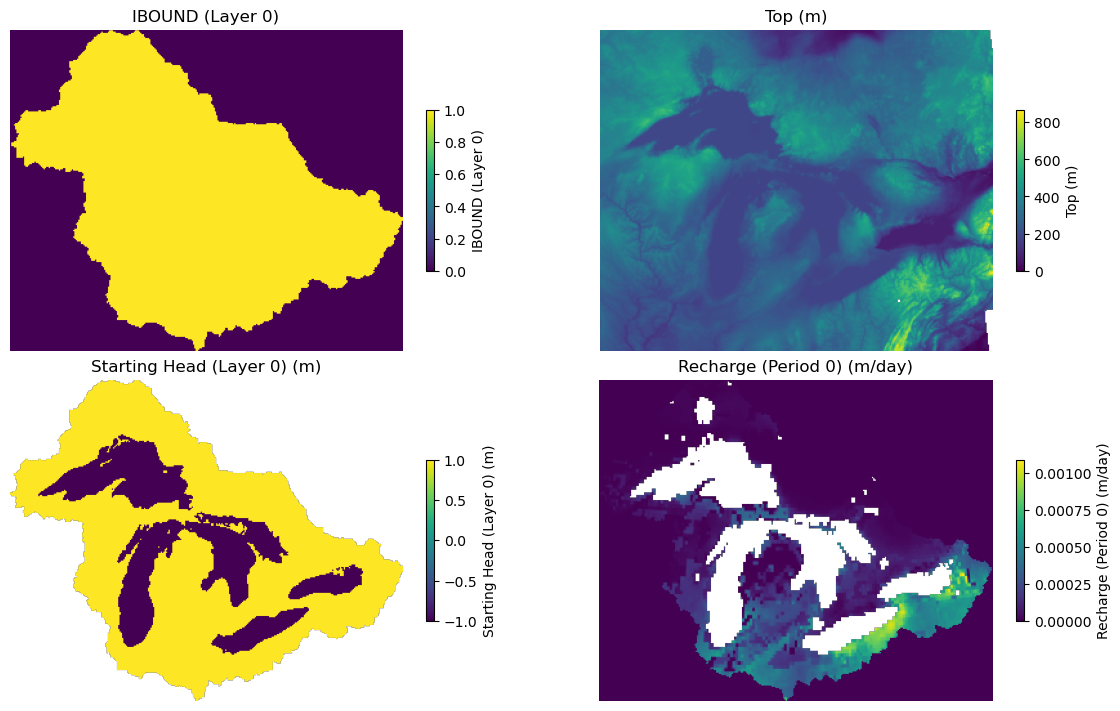

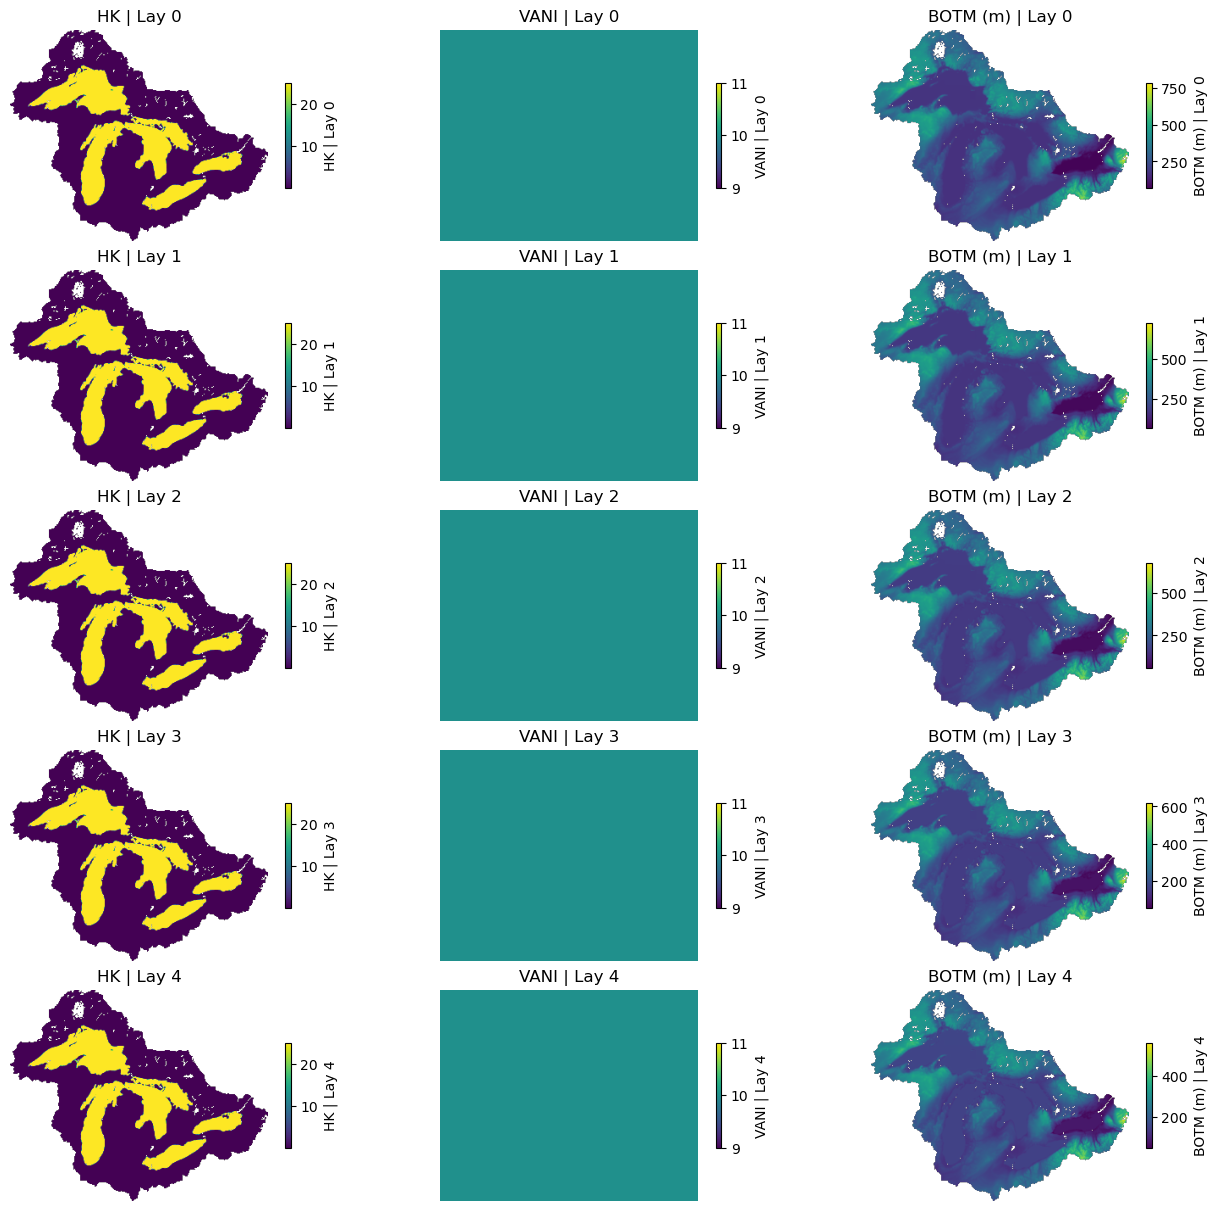

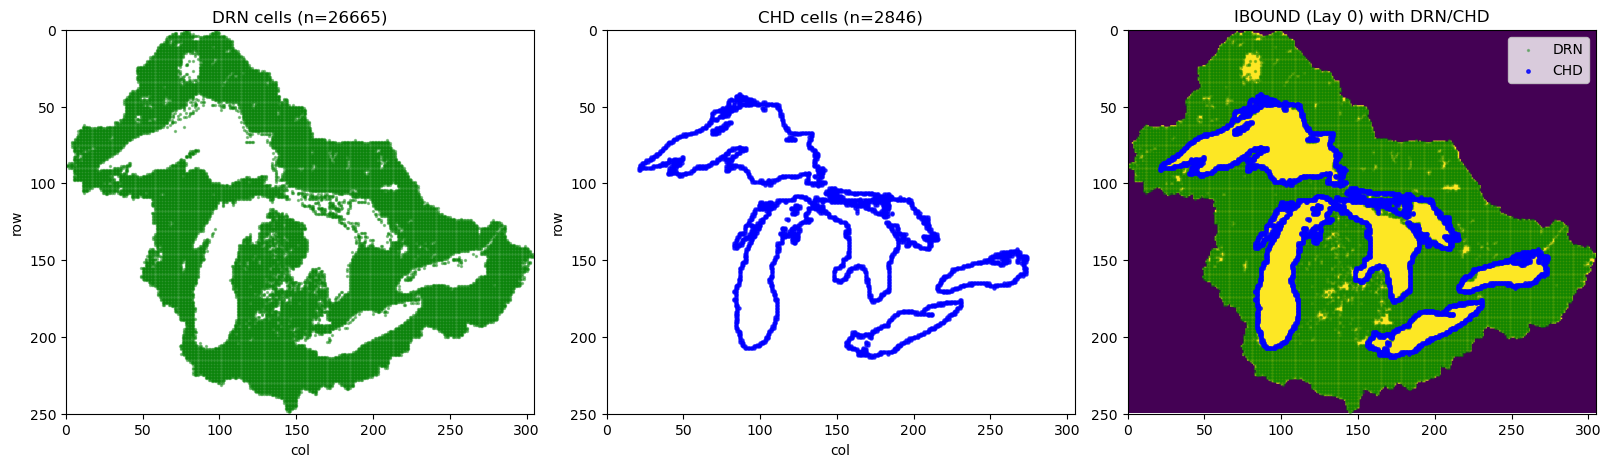

In [115]:
import numpy as np
import matplotlib.pyplot as plt
import rasterio as rio

# --- get transform for plotting ---
with rio.open(template_tif) as tmp:
    grid_transform = tmp.transform

nlay, nrow, ncol = rasterIbound.shape

# --- pick a recharge map to plot (period 0) ---
if "rch_spd" in globals():
    rech0 = rch_spd[0]
elif "rasterRech" in globals():
    rech0 = rasterRech[0] if getattr(rasterRech, "ndim", 2) == 3 else rasterRech
else:
    rech0 = None

# --- helper: robust plot if your plot_raster exists; otherwise fallback to imshow ---
def _plot(ax, arr2d, title, label=None, vmax=None):
    if "plot_raster" in globals():
        plot_raster(arr2d, transform=grid_transform, label=label or title, ax=ax,
                    despine=True, vmax=vmax, title=title)
    else:
        im = ax.imshow(arr2d, origin="upper", vmax=vmax)
        ax.set_title(title)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# =========================================================
# 1) Single-layer overview (2x2)
# =========================================================
top2d = rasterTop[0] if rasterTop.ndim == 3 else rasterTop
start2d = rasterStart[0] if rasterStart.ndim == 3 else rasterStart  # show layer 0

fig, ax = plt.subplots(2, 2, figsize=(12, 7), constrained_layout=True)
ax = ax.flatten()

_plot(ax[0], rasterIbound[0], "IBOUND (Layer 0)")
_plot(ax[1], top2d, "Top (m)")
_plot(ax[2], start2d, "Starting Head (Layer 0) (m)")
if rech0 is not None:
    _plot(ax[3], rech0, "Recharge (Period 0) (m/day)")
else:
    ax[3].set_title("Recharge (not loaded)")
    ax[3].axis("off")

plt.show()

# =========================================================
# 2) Multi-layer rasters (5 layers x 3 datasets)
# =========================================================
listMultiPlot = [rasterHK, rasterVani, rasterBot]
listTitles    = ["HK", "VANI", "BOTM (m)"]
listVmax      = [25, None, None]  # adjust if you want

fig, ax = plt.subplots(nlay, len(listMultiPlot), figsize=(13, 2.4 * nlay), constrained_layout=True)

for lay in range(nlay):
    for j, arr3d in enumerate(listMultiPlot):
        _plot(ax[lay, j], arr3d[lay], f"{listTitles[j]} | Lay {lay}", vmax=listVmax[j])

plt.show()

# =========================================================
# 3) DRN/CHD cells (scatter) + overlay on IBOUND
# =========================================================
fig, ax = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)

# DRN
ax[0].scatter(dfDrn["col"], dfDrn["row"], s=2, c="green", alpha=0.4)
ax[0].set_title(f"DRN cells (n={len(dfDrn)})")
ax[0].set_xlim(0, ncol)
ax[0].set_ylim(nrow, 0)
ax[0].set_aspect("equal", adjustable="box")
ax[0].set_xlabel("col"); ax[0].set_ylabel("row")

# CHD
ax[1].scatter(dfChd["col"], dfChd["row"], s=5, c="blue", alpha=0.7)
ax[1].set_title(f"CHD cells (n={len(dfChd)})")
ax[1].set_xlim(0, ncol)
ax[1].set_ylim(nrow, 0)
ax[1].set_aspect("equal", adjustable="box")
ax[1].set_xlabel("col"); ax[1].set_ylabel("row")

# Overlay on IBOUND
ax[2].imshow(rasterIbound[0], origin="upper")
ax[2].scatter(dfDrn["col"], dfDrn["row"], s=2, c="green", alpha=0.35, label="DRN")
ax[2].scatter(dfChd["col"], dfChd["row"], s=6, c="blue", alpha=0.8, label="CHD")
ax[2].set_title("IBOUND (Lay 0) with DRN/CHD")
ax[2].set_xlim(0, ncol)
ax[2].set_ylim(nrow, 0)
ax[2].legend(loc="upper right")

plt.show()

## Save or Import Prepared Inputs

### Save Prepared Inputs
<div class="alert alert-info">
Run this cell if you want to save the inputs just prepared.
</div>

In [118]:
import os, json
import numpy as np
import pandas as pd

# --- choose an output folder ---
dirModelFiles = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_run\inputs"
os.makedirs(dirModelFiles, exist_ok=True)

# --- output file names ---
out_npz  = os.path.join(dirModelFiles, "inputs_static_5lay.npz")
out_meta = os.path.join(dirModelFiles, "inputs_static_5lay_meta.json")
out_h5   = os.path.join(dirModelFiles, "inputs_tables.h5")   # or parquet, see below

# --- save static arrays ---
np.savez_compressed(
    out_npz,
    rasterTop=rasterTop,
    rasterBot=rasterBot,
    rasterHK=rasterHK,
    rasterVani=rasterVani,
    rasterStart=rasterStart,
    rasterIbound=rasterIbound,
)

# --- metadata (edit recharge_zarr path if yours differs) ---
meta = {
    "structure": structure,
    "template_tif": template_tif,
    "recharge_zarr": r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Recharge\cache\NOAH_Qsb_mday_2000_2025.zarr",
    "recharge_var": "rech_mday",
    "notes": "Static rasters saved in NPZ. Monthly recharge stored in Zarr."
}
with open(out_meta, "w") as f:
    json.dump(meta, f, indent=2)

# --- save tables (HDF) ---
with pd.HDFStore(out_h5, mode="w") as store:
    store["dfChd"] = dfChd
    store["dfDrn"] = dfDrn
    if "dfGrid" in globals():
        store["dfGrid"] = dfGrid

print("✅ Saved arrays:", out_npz)
print("✅ Saved metadata:", out_meta)
print("✅ Saved tables:", out_h5)

C:\Users\abolmaal\AppData\Local\Temp\ipykernel_42572\2156584641.py:38: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block2_values] [items->Index(['cellids'], dtype='object')]

  store["dfChd"] = dfChd
C:\Users\abolmaal\AppData\Local\Temp\ipykernel_42572\2156584641.py:39: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block3_values] [items->Index(['cellids'], dtype='object')]

  store["dfDrn"] = dfDrn


✅ Saved arrays: D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_run\inputs\inputs_static_5lay.npz
✅ Saved metadata: D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_run\inputs\inputs_static_5lay_meta.json
✅ Saved tables: D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_run\inputs\inputs_tables.h5


In [120]:
import os
import numpy as np
import pandas as pd

nlay, nrow, ncol = rasterIbound.shape
lays, rows, cols = np.where(rasterIbound > 0)

dfGrid = pd.DataFrame({"lay": lays.astype(int),
                       "row": rows.astype(int),
                       "col": cols.astype(int)})
dfGrid["cellids"] = list(zip(dfGrid["lay"], dfGrid["row"], dfGrid["col"]))

dfGrid.to_parquet(os.path.join(dirModelFiles, "dfGrid.parquet"), index=False)

print("✅ Rebuilt + saved dfGrid:", os.path.join(dirModelFiles, "dfGrid.parquet"))

✅ Rebuilt + saved dfGrid: D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_run\inputs\dfGrid.parquet


In [121]:
import os

out_tables = os.path.join(dirModelFiles, "inputs_tables.parquet")

# If dfGrid is huge, you may not want to store it; but for 5km grid it’s fine.
dfChd.to_parquet(os.path.join(dirModelFiles, "dfChd.parquet"), index=False)
dfDrn.to_parquet(os.path.join(dirModelFiles, "dfDrn.parquet"), index=False)
dfGrid.to_parquet(os.path.join(dirModelFiles, "dfGrid.parquet"), index=False)

print("✅ Saved dfChd/dfDrn/dfGrid as Parquet in:", dirModelFiles)

✅ Saved dfChd/dfDrn/dfGrid as Parquet in: D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_run\inputs


### Import Prepared Inputs
<div class="alert alert-info">
Run this cell if you want to import previously prepared inputs.
</div>

#### A) Load static rasters + metadata (NPZ + JSON)

In [122]:
import os, json
import numpy as np
import pandas as pd
import xarray as xr

dirModelFiles = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_run\inputs"

npz_path  = os.path.join(dirModelFiles, "inputs_static_5lay.npz")
meta_path = os.path.join(dirModelFiles, "inputs_static_5lay_meta.json")

# --- load rasters ---
static = np.load(npz_path, allow_pickle=True)

rasterTop    = static["rasterTop"]
rasterBot    = static["rasterBot"]
rasterHK     = static["rasterHK"]
rasterVani   = static["rasterVani"]
rasterStart  = static["rasterStart"]
rasterIbound = static["rasterIbound"]

# --- load metadata ---
with open(meta_path, "r") as f:
    meta = json.load(f)

structure    = meta["structure"]
template_tif = meta["template_tif"]

print("✅ Loaded rasters from:", npz_path)
print("Shapes:",
      "TOP", rasterTop.shape,
      "BOT", rasterBot.shape,
      "HK", rasterHK.shape,
      "VANI", rasterVani.shape,
      "START", rasterStart.shape,
      "IBOUND", rasterIbound.shape)

✅ Loaded rasters from: D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_run\inputs\inputs_static_5lay.npz
Shapes: TOP (1, 250, 305) BOT (5, 250, 305) HK (5, 250, 305) VANI (5, 250, 305) START (5, 250, 305) IBOUND (5, 250, 305)


#### B1) Load tables (Parquet version)

In [123]:
dfChd = pd.read_parquet(os.path.join(dirModelFiles, "dfChd.parquet"))
dfDrn = pd.read_parquet(os.path.join(dirModelFiles, "dfDrn.parquet"))

dfGrid_path = os.path.join(dirModelFiles, "dfGrid.parquet")
dfGrid = pd.read_parquet(dfGrid_path) if os.path.exists(dfGrid_path) else None

print("✅ Loaded dfChd/dfDrn", len(dfChd), len(dfDrn))
print("dfGrid loaded:", dfGrid is not None)

✅ Loaded dfChd/dfDrn 2846 26665
dfGrid loaded: True


#### C) Load recharge from Zarr when you need it (monthly transient)

You don’t want to store recharge inside the NPZ. Load it from the cached Zarr:

In [124]:
rech_ds = xr.open_zarr(meta["recharge_zarr"])
rech_da = rech_ds[meta["recharge_var"]]    # (time, y, x)
print("✅ Recharge loaded:", rech_da.shape)

# MF6 needs {per: 2D array}
rch_spd = {k: rech_da.isel(time=k).values.astype("float32")
           for k in range(rech_da.sizes["time"])}
print("rch_spd periods:", len(rch_spd))

✅ Recharge loaded: (562, 250, 306)
rch_spd periods: 562


In [126]:
# Quick Sanity checks
nlay, nrow, ncol = rasterIbound.shape
assert rasterHK.shape == (nlay, nrow, ncol)
assert rasterBot.shape == (nlay, nrow, ncol)
assert rasterVani.shape == (nlay, nrow, ncol)
assert (rasterTop.shape[-2], rasterTop.shape[-1]) == (nrow, ncol)
print("✅ All grids consistent.")

✅ All grids consistent.


# Transient MODFLOW 6 Model
## Build the Model
###  Create a new model object

Create simulation + namefile options

In [128]:
import flopy
import os

nameSim = "GLB_transient"
nameModel = "gwf_glb"

# MODFLOW 6 executable path (use your actual exe)
pathModflowExec = r"C:\Users\abolmaal\Downloads\mf6.exe"   # <-- change to yours

# workspace to write model files
dirModelFiles = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_run\mf6_transient"
os.makedirs(dirModelFiles, exist_ok=True)

# FloPy version string can be omitted; if you want it:
versionString = "mf6"

In [129]:
mfSim = flopy.mf6.MFSimulation(
    sim_name=nameSim,
    version=versionString,      # you can also remove this line entirely
    exe_name=pathModflowExec,
    sim_ws=dirModelFiles
)
mfSim.name_file.nocheck = True

Cell 3 — Build monthly TDIS from recharge dates

Use the monthly dates from your recharge Zarr (dates = pd.to_datetime(rech_da.time.values)).

In [130]:
import calendar
import pandas as pd

dates = pd.to_datetime(dates)  # ensure Timestamp
nper = len(dates)

perioddata = []
for dt in dates:
    perlen = float(calendar.monthrange(int(dt.year), int(dt.month))[1])  # days
    nstp = 1
    tsmult = 1.0
    perioddata.append((perlen, nstp, tsmult))

mfTDIS = flopy.mf6.ModflowTdis(
    mfSim,
    pname="tdis",
    time_units="DAYS",
    nper=nper,
    perioddata=perioddata
)

print("TDIS nper:", nper, "first/last:", dates[0].date(), dates[-1].date())

TDIS nper: 562 first/last: 1979-01-01 2025-10-01


Cell 4 — Create GWF model + solver (IMS)

In [131]:
mfModel = flopy.mf6.ModflowGwf(
    mfSim,
    modelname=nameModel,
    model_nam_file=f"{nameModel}.nam"
)

# Newton under-relaxation (optional but helpful)
mfModel.name_file.newtonoptions = ("UNDER_RELAXATION",)

mfIMS = flopy.mf6.ModflowIms(
    mfSim,
    print_option="SUMMARY",
    complexity="COMPLEX"
)

mfSim.register_ims_package(mfIMS, [mfModel.name])

Cell 5 — DIS (5 layers) + idomain

Use idomain from your IBOUND (MODFLOW 6 uses idomain 0 inactive, 1 active).

In [132]:
# Convert IBOUND-like to idomain (0/1)
idomain = (rasterIbound > 0).astype(np.int32)

top2d = rasterTop[0] if rasterTop.ndim == 3 else rasterTop

mfDIS = flopy.mf6.ModflowGwfdis(
    mfModel,
    nlay=nlay, nrow=nrow, ncol=ncol,
    delr=structure["cellSizeX"],     # NOTE: delr = cellsize in X direction (cols)
    delc=structure["cellSizeY"],     # NOTE: delc = cellsize in Y direction (rows)
    top=top2d,
    botm=rasterBot,
    idomain=idomain,
    length_units="METERS",
    xorigin=structure["xllCorner"],
    yorigin=structure["yllCorner"],
    angrot=0.0,
)

Cell 6 — NPF (HK + VANI)

In [133]:
k = rasterHK.astype(np.float32)
k33 = (rasterHK / rasterVani).astype(np.float32)

mfNPF = flopy.mf6.ModflowGwfnpf(
    mfModel,
    save_flows=True,
    icelltype=1,     # convertible (unconfined)
    k=k,
    k33=k33
)

Cell 7 — STO (transient storage)

Steady for first month, transient afterwards

In [134]:
steady = {0: True}
transient = {0: False}
for per in range(1, nper):
    steady[per] = False
    transient[per] = True

mfSTO = flopy.mf6.ModflowGwfsto(
    mfModel,
    iconvert=1,
    ss=1e-6,
    sy=0.15,
    steady_state=steady,
    transient=transient
)

Cell 8 — IC (starting heads)

In [135]:
mfIC = flopy.mf6.ModflowGwfic(mfModel, strt=rasterStart.astype(np.float32))

Cell 9 — CHD (constant in all stress periods)

You already have dfChd with cellids and head.

Fast way: build a list once and reuse for every period.

In [136]:
chd_spd0 = list(zip(dfChd["cellids"], dfChd["head"].astype(float)))

# same CHD each month
chd_spd = {per: chd_spd0 for per in range(nper)}

mfCHD = flopy.mf6.ModflowGwfchd(
    mfModel,
    stress_period_data=chd_spd,
    save_flows=True
)

Cell 10 — DRN (constant in all stress periods)

You have dfDrn with cellids, elev, cond.

In [137]:
drn_spd0 = list(zip(dfDrn["cellids"], dfDrn["elev"].astype(float), dfDrn["cond"].astype(float)))
drn_spd = {per: drn_spd0 for per in range(nper)}

mfDRN = flopy.mf6.ModflowGwfdrn(
    mfModel,
    stress_period_data=drn_spd,
    save_flows=True
)

Cell 11 — Recharge (monthly transient) using RCHA

This is the key change from steady-state:

In [139]:
nrow, ncol = rasterIbound.shape[1], rasterIbound.shape[2]
print("Model grid:", nrow, ncol)
print("Recharge[0] shape:", rch_spd[0].shape)

Model grid: 250 305
Recharge[0] shape: (250, 306)


In [140]:
import xarray as xr
import numpy as np

nrow, ncol = rasterIbound.shape[1], rasterIbound.shape[2]

# reload from zarr (recommended so you don't keep the wrong-shape dict)
ds = xr.open_zarr(r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Recharge\cache\NOAH_Qsb_mday_2000_2025.zarr")
rech = ds["rech_mday"]   # (time, y, x)

print("Original rech shape:", rech.shape)

# crop to model grid
rech = rech.isel(y=slice(0, nrow), x=slice(0, ncol))
print("Cropped rech shape:", rech.shape)

# rebuild dict for MF6
nper = rech.sizes["time"]
rch_spd = {k: rech.isel(time=k).values.astype("float32") for k in range(nper)}

print("rch_spd[0] shape:", rch_spd[0].shape)

Original rech shape: (562, 250, 306)
Cropped rech shape: (562, 250, 305)
rch_spd[0] shape: (250, 305)


In [141]:
mfRCHA = flopy.mf6.ModflowGwfrcha(
    mfModel,
    readasarrays=True,
    recharge=rch_spd,
    pname="rcha",
    save_flows=True
)

Cell 12 — Output control

In [142]:
pathOutputBudget = f"{nameModel}.cbc"
pathOutputHead   = f"{nameModel}.hds"

mfOC = flopy.mf6.ModflowGwfoc(
    mfModel,
    saverecord=[("HEAD", "ALL"), ("BUDGET", "ALL")],
    printrecord=[("HEAD", "LAST"), ("BUDGET", "LAST")],
    head_filerecord=pathOutputHead,
    budget_filerecord=pathOutputBudget
)

Cell 13 — Write + run

In [147]:
import numpy as np

nlay, nrow, ncol = rasterIbound.shape
top2d = rasterTop[0] if rasterTop.ndim == 3 else rasterTop
botm = rasterBot  # (nlay,nrow,ncol)

idomain = (rasterIbound > 0)

print("TOP NaN%:", np.isnan(top2d).mean()*100)
print("BOTM NaN% by layer:", [np.isnan(botm[k]).mean()*100 for k in range(nlay)])

# Build per-layer "top of layer"
top_of = np.empty_like(botm, dtype="float32")
top_of[0] = top2d
if nlay > 1:
    top_of[1:] = botm[:-1]

# thickness
thk = top_of - botm
bad_thk = (thk <= 0) & idomain
print("Bad thickness cells (count) by layer:", [int(bad_thk[k].sum()) for k in range(nlay)])

bad_nan = (~np.isfinite(top2d))[None, :, :] | (~np.isfinite(botm))
bad_nan = bad_nan & idomain
print("Active cells with NaN/Inf by layer:", [int(bad_nan[k].sum()) for k in range(nlay)])

TOP NaN%: 0.2334426229508197
BOTM NaN% by layer: [np.float64(49.49245901639344), np.float64(49.49245901639344), np.float64(49.49245901639344), np.float64(49.49245901639344), np.float64(49.49245901639344)]
Bad thickness cells (count) by layer: [690, 690, 690, 690, 690]
Active cells with NaN/Inf by layer: [609, 609, 609, 609, 609]


In [148]:
import numpy as np

nlay, nrow, ncol = rasterIbound.shape
top2d = rasterTop[0] if rasterTop.ndim == 3 else rasterTop
botm = rasterBot.astype("float32")

# start from your existing idomain
idomain = (rasterIbound > 0).astype(np.int32)

# Build per-layer top-of-layer
top_of = np.empty_like(botm, dtype="float32")
top_of[0] = top2d.astype("float32")
if nlay > 1:
    top_of[1:] = botm[:-1]

# Identify bad cells (any layer problem)
bad = np.zeros((nrow, ncol), dtype=bool)

# top invalid
bad |= ~np.isfinite(top2d)

# any botm invalid OR botm >= layer top (bad thickness)
for k in range(nlay):
    bad |= ~np.isfinite(botm[k])
    bad |= (botm[k] >= top_of[k])   # zero/negative thickness

# Deactivate bad cells in ALL layers
idomain[:, bad] = 0

# Fill TOP/BOTM in inactive cells with finite values so DIS won’t crash
top2d_safe = top2d.astype("float32").copy()
top2d_safe[bad] = 0.0

botm_safe = botm.copy()
for k in range(nlay):
    botm_safe[k, bad] = -(k + 1) * 10.0   # arbitrary decreasing values

# Update globals used later
rasterIbound = idomain.astype("int16")
rasterTop = top2d_safe[np.newaxis, :, :]     # keep (1,nrow,ncol)
rasterBot = botm_safe

print("✅ Sanitized arrays")
print("Active cells total:", int((idomain > 0).sum()))
print("TOP NaN%:", np.isnan(rasterTop[0]).mean() * 100)
print("BOTM NaN% by layer:", [np.isnan(rasterBot[k]).mean() * 100 for k in range(nlay)])

✅ Sanitized arrays
Active cells total: 187015
TOP NaN%: 0.0
BOTM NaN% by layer: [np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)]


In [150]:
import rasterio as rio
import flopy
import numpy as np

top2d = rasterTop[0]
botm = rasterBot
idomain = (rasterIbound > 0).astype(np.int32)

with rio.open(template_tif) as tmp:
    delr = float(tmp.res[0])
    delc = float(tmp.res[1])
    xorigin = float(tmp.bounds.left)
    yorigin = float(tmp.bounds.bottom)

# Remove existing DIS if present (FloPy-compatible)
old_dis = mfModel.get_package("dis")
if old_dis is not None:
    mfModel.remove_package(old_dis)

mfDIS = flopy.mf6.ModflowGwfdis(
    mfModel,
    nlay=idomain.shape[0],
    nrow=idomain.shape[1],
    ncol=idomain.shape[2],
    delr=delr,
    delc=delc,
    top=top2d,
    botm=botm,
    idomain=idomain,
    length_units="METERS",
    xorigin=xorigin,
    yorigin=yorigin,
    angrot=0.0,
)

print("✅ DIS rebuilt.")
print("Packages now:", mfModel.get_package_list())

✅ DIS rebuilt.
Packages now: ['NPF', 'STO', 'IC', 'CHD_0', 'DRN_0', 'RCHA', 'OC', 'DIS']


In [145]:
mfSim = flopy.mf6.MFSimulation(
    sim_name=nameSim,
    exe_name=pathModflowExec,
    sim_ws=dirModelFiles
)

In [153]:
import os
import flopy
import numpy as np
import pandas as pd
import calendar
import rasterio as rio

nameSim = "GLB_transient"
nameModel = "gwf_glb"

pathModflowExec = r"D:\Users\abolmaal\modelling\Modflow\helper\mf6.exe"
dirModelFiles = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_run\mf6_transient"
os.makedirs(dirModelFiles, exist_ok=True)

In [154]:
import os
import flopy
import numpy as np
import pandas as pd
import calendar
import rasterio as rio

nameSim = "GLB_transient"
nameModel = "gwf_glb"

pathModflowExec = r"D:\Users\abolmaal\modelling\Modflow\helper\mf6.exe"
dirModelFiles = r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_run\mf6_transient"
os.makedirs(dirModelFiles, exist_ok=True)

In [155]:
dates = pd.to_datetime(dates)
nper = len(dates)

perioddata = []
for dt in dates:
    perlen = float(calendar.monthrange(int(dt.year), int(dt.month))[1])  # days
    perioddata.append((perlen, 1, 1.0))  # (perlen, nstp, tsmult)

mfTDIS = flopy.mf6.ModflowTdis(
    mfSim,
    time_units="DAYS",
    nper=nper,
    perioddata=perioddata
)

In [156]:
mfModel = flopy.mf6.ModflowGwf(
    mfSim,
    modelname=nameModel,
    model_nam_file=f"{nameModel}.nam"
)
mfModel.name_file.newtonoptions = ("UNDER_RELAXATION",)

In [157]:
mfIMS = flopy.mf6.ModflowIms(
    mfSim,
    print_option="SUMMARY",
    complexity="COMPLEX"
)
mfSim.register_ims_package(mfIMS, [mfModel.name])

In [158]:
nlay, nrow, ncol = rasterIbound.shape
idomain = (rasterIbound > 0).astype(np.int32)

top2d = rasterTop[0] if rasterTop.ndim == 3 else rasterTop

with rio.open(template_tif) as tmp:
    delr = float(tmp.res[0])
    delc = float(tmp.res[1])
    xorigin = float(tmp.bounds.left)
    yorigin = float(tmp.bounds.bottom)

mfDIS = flopy.mf6.ModflowGwfdis(
    mfModel,
    nlay=nlay, nrow=nrow, ncol=ncol,
    delr=delr, delc=delc,
    top=top2d,
    botm=rasterBot,
    idomain=idomain,
    length_units="METERS",
    xorigin=xorigin,
    yorigin=yorigin,
    angrot=0.0,
)

In [159]:
k = rasterHK.astype(np.float32)
k33 = (rasterHK / rasterVani).astype(np.float32)

mfNPF = flopy.mf6.ModflowGwfnpf(
    mfModel,
    save_flows=True,
    icelltype=1,
    k=k,
    k33=k33
)

In [160]:
steady = {0: True}
transient = {0: False}
for per in range(1, nper):
    steady[per] = False
    transient[per] = True

mfSTO = flopy.mf6.ModflowGwfsto(
    mfModel,
    iconvert=1,
    ss=1e-6,
    sy=0.15,
    steady_state=steady,
    transient=transient
)

In [161]:
mfIC = flopy.mf6.ModflowGwfic(mfModel, strt=rasterStart.astype(np.float32))

In [162]:
chd_spd0 = list(zip(dfChd["cellids"], dfChd["head"].astype(float)))
chd_spd = {per: chd_spd0 for per in range(nper)}

mfCHD = flopy.mf6.ModflowGwfchd(
    mfModel,
    stress_period_data=chd_spd,
    save_flows=True
)

In [163]:
drn_spd0 = list(zip(dfDrn["cellids"], dfDrn["elev"].astype(float), dfDrn["cond"].astype(float)))
drn_spd = {per: drn_spd0 for per in range(nper)}

mfDRN = flopy.mf6.ModflowGwfdrn(
    mfModel,
    stress_period_data=drn_spd,
    save_flows=True
)

In [164]:
# safety check
assert rch_spd[0].shape == (nrow, ncol), (rch_spd[0].shape, (nrow, ncol))
assert len(rch_spd) == nper, (len(rch_spd), nper)

mfRCHA = flopy.mf6.ModflowGwfrcha(
    mfModel,
    readasarrays=True,
    recharge=rch_spd,
    pname="rcha",
    save_flows=True
)

In [165]:
mfOC = flopy.mf6.ModflowGwfoc(
    mfModel,
    saverecord=[("HEAD", "ALL"), ("BUDGET", "ALL")],
    printrecord=[("HEAD", "LAST"), ("BUDGET", "LAST")],
    head_filerecord=f"{nameModel}.hds",
    budget_filerecord=f"{nameModel}.cbc"
)

In [167]:
import numpy as np
import pandas as pd
import flopy
import ast

# active mask from sanitized idomain
idomain = (rasterIbound > 0).astype(np.int32)
nlay, nrow, ncol = idomain.shape

# ---- copy + ensure types ----
dfDrn2 = dfDrn.copy()

# if cellids got saved as strings (parquet/hdf), this prevents surprises later
if isinstance(dfDrn2["cellids"].iloc[0], str):
    dfDrn2["cellids"] = dfDrn2["cellids"].apply(ast.literal_eval)

if "lay" not in dfDrn2.columns:
    dfDrn2["lay"] = 0

dfDrn2["lay"]  = dfDrn2["lay"].astype(int)
dfDrn2["row"]  = dfDrn2["row"].astype(int)
dfDrn2["col"]  = dfDrn2["col"].astype(int)
dfDrn2["elev"] = dfDrn2["elev"].astype(float)
dfDrn2["cond"] = dfDrn2["cond"].astype(float)

# ---- filter to in-range + active cells ----
in_range = (
    (dfDrn2["lay"] >= 0) & (dfDrn2["lay"] < nlay) &
    (dfDrn2["row"] >= 0) & (dfDrn2["row"] < nrow) &
    (dfDrn2["col"] >= 0) & (dfDrn2["col"] < ncol)
)
dfDrn2 = dfDrn2.loc[in_range].copy()

active = idomain[dfDrn2["lay"].to_numpy(), dfDrn2["row"].to_numpy(), dfDrn2["col"].to_numpy()] > 0
dfDrn2 = dfDrn2.loc[active].copy()

print("DRN kept after idomain filter:", len(dfDrn2), "of", len(dfDrn))

# ---- IMPORTANT: flattened record format ----
# each record: [lay, row, col, elev, cond]
drn_spd0 = dfDrn2[["lay", "row", "col", "elev", "cond"]].values.tolist()

# ---- remove any existing DRN packages (version-safe) ----
for p in list(mfModel.packagelist):
    ptype = (getattr(p, "package_type", "") or "").lower()
    if ptype == "drn":
        mfModel.remove_package(p)

# ---- add DRN back (only period 0 needed; it persists) ----
mfDRN = flopy.mf6.ModflowGwfdrn(
    mfModel,
    stress_period_data={0: drn_spd0},
    save_flows=True,
    pname="drn"
)

print("✅ DRN rebuilt with flattened [lay,row,col,elev,cond] records.")

DRN kept after idomain filter: 26473 of 26665
✅ DRN rebuilt with flattened [lay,row,col,elev,cond] records.


In [176]:
#Rebuild CHD correctly (and filter inactive cells)
import numpy as np
import pandas as pd
import flopy
import ast

idomain = (rasterIbound > 0).astype(np.int32)
nlay, nrow, ncol = idomain.shape

dfChd2 = dfChd.copy()

# if cellids are strings (from parquet/hdf), convert back to tuples
if isinstance(dfChd2["cellids"].iloc[0], str):
    dfChd2["cellids"] = dfChd2["cellids"].apply(ast.literal_eval)

# make sure lay/row/col are ints
dfChd2["lay"] = dfChd2["lay"].astype(int)
dfChd2["row"] = dfChd2["row"].astype(int)
dfChd2["col"] = dfChd2["col"].astype(int)
dfChd2["head"] = dfChd2["head"].astype(float)

# keep only in-range + active cells
in_range = (
    (dfChd2["lay"] >= 0) & (dfChd2["lay"] < nlay) &
    (dfChd2["row"] >= 0) & (dfChd2["row"] < nrow) &
    (dfChd2["col"] >= 0) & (dfChd2["col"] < ncol)
)
dfChd2 = dfChd2.loc[in_range].copy()

active = idomain[dfChd2["lay"].to_numpy(), dfChd2["row"].to_numpy(), dfChd2["col"].to_numpy()] > 0
dfChd2 = dfChd2.loc[active].copy()

print("CHD kept:", len(dfChd2), "of", len(dfChd))

# build CHD records: ((lay,row,col), head)
chd_spd0 = [((int(l), int(r), int(c)), float(h))
           for l, r, c, h in zip(dfChd2["lay"], dfChd2["row"], dfChd2["col"], dfChd2["head"])]

# remove any existing CHD packages
for pkg in list(mfModel.packagelist):
    if (getattr(pkg, "package_type", "") or "").lower() == "chd":
        mfModel.remove_package(pkg)

# add CHD back (only period 0 needed; it persists)
mfCHD = flopy.mf6.ModflowGwfchd(
    mfModel,
    stress_period_data={0: chd_spd0},
    save_flows=True,
    pname="chd"
)

print("✅ CHD rebuilt. First record:", chd_spd0[0])

CHD kept: 2740 of 2846
✅ CHD rebuilt. First record: ((0, 42, 86), 175.0)


Option A — Drop invalid CHD cells (head <= bottom) + rebuild CHD

Run this after you have rasterTop/rasterBot/rasterIbound sanitized and after you built dfChd2 (the one you printed “CHD kept 2740 …”).

In [178]:
import numpy as np
import flopy

# Active mask
idomain = (rasterIbound > 0).astype(np.int32)
nlay, nrow, ncol = idomain.shape

# Use the filtered/active CHD df you already made (dfChd2)
# (If you only have dfChd, then set dfChd2 = dfChd.copy() first)
df = dfChd2.copy()

# Ensure ints
df["lay"] = df["lay"].astype(int)
df["row"] = df["row"].astype(int)
df["col"] = df["col"].astype(int)
df["head"] = df["head"].astype(float)

rows = df["row"].to_numpy()
cols = df["col"].to_numpy()
lays = df["lay"].to_numpy()

# Bottom elevation at each CHD cell
bot = rasterBot[lays, rows, cols].astype(float)

eps = 1e-3  # 1 mm
keep = df["head"].to_numpy() > (bot + eps)

print("CHD removed (head<=bot):", int((~keep).sum()))
print("CHD kept:", int(keep.sum()))

df = df.loc[keep].copy()

# Build CHD stress period data (period 0 only; persists)
chd_spd0 = [((int(l), int(r), int(c)), float(h))
           for l, r, c, h in zip(df["lay"], df["row"], df["col"], df["head"])]

# Remove existing CHD packages
for pkg in list(mfModel.packagelist):
    if (getattr(pkg, "package_type", "") or "").lower() == "chd":
        mfModel.remove_package(pkg)

# Add CHD back
mfCHD = flopy.mf6.ModflowGwfchd(
    mfModel,
    stress_period_data={0: chd_spd0},
    save_flows=True,
    pname="chd"
)

print("✅ Rebuilt CHD with valid heads. maxbound:", len(chd_spd0))

CHD removed (head<=bot): 1663
CHD kept: 1077
✅ Rebuilt CHD with valid heads. maxbound: 1077


In [191]:
import os
from pathlib import Path
import rasterio as rio
from rasterio.warp import reproject, Resampling

# Use the correct template
template_tif = idomain_tif

ALIGNED_DIR = Path(r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\ALIGNED_3174")
ALIGNED_DIR.mkdir(parents=True, exist_ok=True)

def warp_raster_to_template(src_path, template_path, out_path, resampling, dst_nodata=None):
    with rio.open(template_path) as tmpl, rio.open(src_path) as src:
        dst_crs = tmpl.crs
        dst_transform = tmpl.transform
        dst_width = tmpl.width
        dst_height = tmpl.height

        src_nodata = src.nodata
        if dst_nodata is None:
            dst_nodata = src_nodata

        dst_meta = src.meta.copy()
        dst_meta.update(
            driver="GTiff",
            crs=dst_crs,
            transform=dst_transform,
            width=dst_width,
            height=dst_height,
            nodata=dst_nodata,
            compress="deflate",
            tiled=True,
            BIGTIFF="YES",
            blockxsize=256,
            blockysize=256,
        )

        with rio.open(out_path, "w", **dst_meta) as dst:
            for b in range(1, src.count + 1):
                reproject(
                    source=rio.band(src, b),
                    destination=rio.band(dst, b),
                    src_transform=src.transform,
                    src_crs=src.crs,
                    src_nodata=src_nodata,
                    dst_transform=dst_transform,
                    dst_crs=dst_crs,
                    dst_nodata=dst_nodata,
                    resampling=resampling,
                )
    print("Wrote:", out_path)
    return out_path

# Continuous rasters -> bilinear
top_aligned  = str(ALIGNED_DIR / "TOP_5000m.tif")
botm_aligned = str(ALIGNED_DIR / "BOTM_5000m.tif")
hk_aligned   = str(ALIGNED_DIR / "HK_5000m.tif")
start_aligned = str(ALIGNED_DIR / "START_5000m.tif")

warp_raster_to_template(nameInputTop,      template_tif, top_aligned,  Resampling.bilinear, dst_nodata=-9999.0)
warp_raster_to_template(nameInputLayBot,   template_tif, botm_aligned, Resampling.bilinear, dst_nodata=-9999.0)
warp_raster_to_template(nameInputHorizCond,template_tif, hk_aligned,   Resampling.bilinear, dst_nodata=-9999.0)

# If this really is starting heads (continuous), bilinear; if it’s a mask, use nearest
warp_raster_to_template(nameInputStart, template_tif, start_aligned, Resampling.bilinear, dst_nodata=-9999.0)

Wrote: D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\ALIGNED_3174\TOP_5000m.tif
Wrote: D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\ALIGNED_3174\BOTM_5000m.tif
Wrote: D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\ALIGNED_3174\HK_5000m.tif
Wrote: D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\ALIGNED_3174\START_5000m.tif


'D:\\Users\\abolmaal\\modelling\\Modflow\\Prep\\GreatLakes\\model_Layers\\ALIGNED_3174\\START_5000m.tif'

In [188]:
template_tif = idomain_tif

# rebuild id2d from idomain
id2d = (read_band1(idomain_tif, dtype="int32")[0] > 0).astype("int32")

# rebuild rch_spd using the fixed template_tif
rch_spd = {}
bad = []
for per, (dt, pth) in enumerate(zip(df_nc["date"], df_nc["path"])):
    try:
        rch_spd[per] = qsb_month_to_rech_mday_on_template(pth, template_tif, var="Qsb", id2d=id2d)
    except Exception as e:
        bad.append((per, str(dt.date()), pth, repr(e)))
        with rio.open(template_tif) as tmp:
            rch_spd[per] = np.zeros((tmp.height, tmp.width), dtype="float32")

print("rch_spd built:", len(rch_spd), "bad:", len(bad))

rch_spd built: 562 bad: 0


In [189]:
with rio.open(template_tif) as tmp:
    tshape = (tmp.height, tmp.width)
    tcrs = tmp.crs
    ttr = tmp.transform

def assert_match(path, name):
    with rio.open(path) as src:
        assert (src.height, src.width) == tshape, f"{name} shape {src.height,src.width} != template {tshape}"
        assert src.crs == tcrs, f"{name} CRS {src.crs} != template {tcrs}"
        assert src.transform == ttr, f"{name} transform != template"

assert_match(idomain_tif, "IDOMAIN")
assert_match(top_aligned, "TOP")
assert_match(botm_aligned, "BOTM")
assert_match(hk_aligned, "HK")
print("All core rasters match template ✅", tshape)

All core rasters match template ✅ (250, 306)


In [193]:
import os

rch_file = os.path.join(sim_ws, f"{nameModel}.rch")
print("RCH file:", rch_file, "exists?", os.path.exists(rch_file),
      "size:", os.path.getsize(rch_file) if os.path.exists(rch_file) else None)

if os.path.exists(rch_file):
    with open(rch_file, "r") as f:
        for i in range(40):
            line = f.readline()
            if not line:
                break
            print(line.rstrip())

RCH file: D:\Users\abolmaal\modelling\Modflow\Testing\gwf_glb.rch exists? False size: None


In [192]:
sim.write_simulation()
ok, buff = sim.run_simulation()
print("Run success:", ok)
if not ok:
    print("\n".join(buff[-80:]))  # last lines usually show the cause

writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims...
  writing model Testing...
    writing model name file...
    writing package dis...
    writing package npf...
    writing package chd...
INFORMATION: maxbound in ('', 'chd', 'dimensions') changed to 2846 based on size of stress_period_data
    writing package drn...
INFORMATION: maxbound in ('', 'drn', 'dimensions') changed to 26665 based on size of stress_period_data
    writing package rch...
    writing package rcha...
    writing package sto...
FloPy is using the following executable to run the model: ..\helper\mf6.exe
                                   MODFLOW 6
                U.S. GEOLOGICAL SURVEY MODULAR HYDROLOGIC MODEL
                            VERSION 6.6.3 09/29/2025

   MODFLOW 6 compiled Oct 07 2025 23:07:48 with Intel(R) Fortran Intel(R) 64
   Compiler Classic for applications running on Intel(R) 64, Version 2021.7.0
                        